# Backtest 005d - TTM Breakout Squeeze + AVWAP Filter

Fork of `backtest_005.ipynb` with an Anchored VWAP filter added on top of the TTM breakout entries.

## Strategy logic

| Version | Entry condition |
|---------|----------------|
| **v1** | `no_squeeze` AND `TTM momentum > 0` |
| **v2** | `no_squeeze` AND `TTM momentum crossed above 0` (up to 3 bars look-back) |
| **v3** | Squeeze JUST released AND (`momentum > 0` OR `consecutive_neg > threshold`) OR Williams VIX Fix signal |

**AVWAP filter:** final entry must also satisfy `close > AVWAP(lowest).shift(1)`

**Exit:** ATR trailing stop (multiplier optimised via Optuna)

**Optimisation:** Multi-objective Optuna - maximise `Total Return (%)` and `Sortino Ratio`


In [20]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numba as nb
import vectorbt as vbt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import talib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl import atr_trailing_nb
from backend.app.services.indicators.vwap import avwap_func_nb
from backend.app.services.indicators.wiliams_vix_fix import williams_vix_fix_indicator

plt.style.use('dark_background')
print('imports ok')

imports ok


## 1. Load Data

In [21]:
from backend.app.services.data_loader import load_stocks

df_raw = load_stocks()

open_  = df_raw['open']
high   = df_raw['high']
low    = df_raw['low']
close  = df_raw['close']
volume = df_raw['volume']

close.tail(3)


Loading from HDF5 cache: stocks_data_latest.h5
Shape: (2540, 1000)  |  2016-08-22 → 2026-08-21


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-08-19,6.90,16.8,21.80,40.8,8.05,11.00,12.70,16.75,6.10,5.92,...,1726.69,63.1,10.95,24.85,1.81,62.7,24.10,14.55,56.8,7.54
2026-08-20,6.90,17.0,21.95,40.9,8.15,11.00,12.75,16.70,6.00,5.89,...,1734.24,64.0,10.90,24.90,1.76,63.5,24.15,14.30,55.2,7.51
2026-08-21,7.12,17.0,22.75,41.5,8.23,11.05,13.30,17.15,5.96,5.90,...,1768.12,63.8,11.25,25.70,1.82,65.0,25.30,15.30,54.6,7.65


## 2. TTM Breakout Helpers

In [22]:
# ── copied from backend/app/services/strategies/breakout_ttm.py ───────────────
from backend.app.services.indicators.kama import kama_2d, slope_flat_2d

from backend.app.services.indicators.common import shift_2d, count_consecutive_neg_2d


@nb.njit
def _early_exit_nb(close_2d, low_2d, entries_2d, window, pct):
    """
    For each symbol: after an entry, if the bar LOW drops > pct from entry close
    within the first  bars, emit an exit signal.
    Uses low (not close) so intraday wicks are captured as true MAE.
    """
    n_rows, n_cols = close_2d.shape
    out = np.zeros((n_rows, n_cols), dtype=np.bool_)
    for col in range(n_cols):
        entry_bar   = -1
        entry_close = np.nan
        for row in range(n_rows):
            if entries_2d[row, col]:
                entry_bar   = row
                entry_close = close_2d[row, col]
            if entry_bar >= 0:
                bars_since = row - entry_bar
                if 1 <= bars_since <= window:
                    mae = (entry_close - low_2d[row, col]) / entry_close
                    if mae > pct:
                        out[row, col] = True
                        entry_bar = -1   # stop watching after firing
    return out


def early_exit_signal(close, low, entries, window=5, pct=0.05):
    """Returns a boolean exit DataFrame: fires when MAE (low-based) > pct within  bars of entry."""
    result = _early_exit_nb(
        close.to_numpy().astype(np.float64),
        low.to_numpy().astype(np.float64),
        entries.to_numpy().astype(np.bool_),
        window, pct,
    )
    return pd.DataFrame(result, index=close.index, columns=close.columns)


@nb.njit
def _max_hold_exit_nb(entries_2d, max_hold_days):
    """Exit when bars held since last entry exceed max_hold_days."""
    n_rows, n_cols = entries_2d.shape
    out = np.zeros((n_rows, n_cols), dtype=np.bool_)
    for col in range(n_cols):
        entry_bar = -1
        for row in range(n_rows):
            if entries_2d[row, col]:
                entry_bar = row
            if entry_bar >= 0:
                if row - entry_bar > max_hold_days:
                    out[row, col] = True
                    entry_bar = -1
    return out


def max_hold_exit_signal(entries, max_hold_days=160):
    """Exit when position held longer than max_hold_days (daily bars)."""
    result = _max_hold_exit_nb(entries.to_numpy().astype(np.bool_), max_hold_days)
    return pd.DataFrame(result, index=entries.index, columns=entries.columns)


print('early_exit_signal defined (MAE = low-based)')
print('max_hold_exit_signal defined (>30d default)')

print('Numba helpers compiled')


early_exit_signal defined (MAE = low-based)
max_hold_exit_signal defined (>30d default)
Numba helpers compiled


In [23]:
AVWAP = vbt.IndicatorFactory(
    class_name='AVWAP',
    short_name='avwap',
    input_names=['close', 'high', 'low', 'volume'],
    param_names=['is_highest', 'window'],
    output_names=['avwap'],
).from_apply_func(avwap_func_nb)

_avwap_lowest_cache = {}


def get_avwap_lowest(close, high, low, volume, window: int = 200):
    key = (id(close), id(high), id(low), id(volume), int(window))
    if key not in _avwap_lowest_cache:
        avwap = AVWAP.run(
            close, high, low, volume,
            is_highest=[False],
            window=int(window),
        ).avwap
        avwap_lowest = avwap.xs(False, level='avwap_is_highest', axis=1)
        avwap_lowest.columns = avwap_lowest.columns.get_level_values(-1)
        _avwap_lowest_cache[key] = avwap_lowest.reindex(columns=close.columns)
    return _avwap_lowest_cache[key]


def compute_signals(
    close, high, low, volume,
    # BB params
    bb_window:                int   = 16,
    bb_multiplier:            float = 1.0,
    bb_matype:                int   = 0,
    # Keltner params
    kc_window:                int   = 40,
    kc_multiplier:            float = 1.2,
    kc_atr_period:            int   = 10,
    # TTM oscillator params
    donichan_window:          int   = 12,
    osc_smoothing_period:     int   = 10,
    # Entry version
    entry_version:            str   = 'v3',
    consecutive_neg_threshold:int   = 7,
    # Williams VIX Fix
    william_vix_period:       int   = 20,
    # AVWAP filter
    # use_avwap_filter:         bool  = True,
    # avwap_window:             int   = 200,
    # KAMA slope filter (breakout entries only)
    use_kama_slope:           bool  = True,
    kama_period:              int   = 10,
    kama_fast:                int   = 2,
    kama_slow:                int   = 30,
    kama_slope_win:           int   = 5,
    flat_threshold_pct:       float = 1.0,
    # Near-recent-low filter: close must be within max_pct of rolling min close
    use_near_low_filter:      bool  = True,
    near_low_window:          int   = 5,
    near_low_max_pct:         float = 10.0,
):
    """
    Compute TTM Breakout entry signals.

    KAMA slope gate applies only to breakout-type entries:
      v1, v2    : full signal gated by flat KAMA slope
      v3 entry_1: squeeze-release breakout - gated by flat KAMA slope
      v3 entry_2: bottom-fishing (extended neg momentum) - NOT gated
      v3 WVF    : volatility spike / contrarian - NOT gated

    Near-low filter (optional): at entry, (close - MIN(close, N)) / MIN(close, N)
      must be < near_low_max_pct — avoids buying too far above recent lows.

    AVWAP gate applies after the TTM logic:
      final entry must also satisfy close > AVWAP(lowest).shift(1)
    """
    BB   = vbt.IndicatorFactory.from_talib('BBANDS')
    ATR  = vbt.IndicatorFactory.from_talib('ATR')
    EMA  = vbt.IndicatorFactory.from_talib('EMA')
    SMA  = vbt.IndicatorFactory.from_talib('SMA')
    MAX  = vbt.IndicatorFactory.from_talib('MAX')
    MIN  = vbt.IndicatorFactory.from_talib('MIN')
    LREG = vbt.IndicatorFactory.from_talib('LINEARREG')

    # indicators -> numpy
    bb  = BB.run(close, timeperiod=bb_window,
                 nbdevup=bb_multiplier, nbdevdn=bb_multiplier, matype=bb_matype)
    atr = ATR.run(high, low, close, timeperiod=kc_atr_period)
    ema = EMA.run(close, timeperiod=kc_window)

    bb_upper_np  = bb.upperband.to_numpy()
    bb_lower_np  = bb.lowerband.to_numpy()
    ema_np       = ema.real.to_numpy()
    atr_np       = atr.real.to_numpy()
    kc_upper_np  = ema_np + kc_multiplier * atr_np
    kc_lower_np  = ema_np - kc_multiplier * atr_np

    hh  = MAX.run(high, timeperiod=donichan_window).real.to_numpy()
    ll  = MIN.run(low,  timeperiod=donichan_window).real.to_numpy()
    sma = SMA.run(close, timeperiod=donichan_window).real.to_numpy()
    close_np  = close.to_numpy()
    histogram = close_np - ((hh + ll) / 2 + sma) / 2
    ttms_np   = LREG.run(
        pd.DataFrame(histogram, index=close.index, columns=close.columns),
        timeperiod=osc_smoothing_period,
    ).real.to_numpy()

    # if use_avwap_filter:
    #     avwap_lowest = get_avwap_lowest(close, high, low, volume, avwap_window)
    #     avwap_prev_np = shift_2d(avwap_lowest.to_numpy(dtype=np.float64), 1)
    #     avwap_filter_np = (close_np > avwap_prev_np) & (~np.isnan(avwap_prev_np))
    # else:
    #     avwap_filter_np = np.ones_like(close_np, dtype=np.bool_)

    if use_kama_slope:
        kama_np = kama_2d(close_np.astype(np.float64), kama_period, kama_fast, kama_slow)
        flat_np = slope_flat_2d(kama_np, kama_slope_win, flat_threshold_pct)
    else:
        flat_np = np.ones_like(close_np, dtype=np.bool_)

    if entry_version == 'v1':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        entries_np = no_sqz_np & (ttms_np > 0) & flat_np

    elif entry_version == 'v2':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        ttms_1 = shift_2d(ttms_np, 1)
        ttms_2 = shift_2d(ttms_np, 2)
        ttms_3 = shift_2d(ttms_np, 3)
        crossed_now  = (ttms_1  < 0) & (ttms_np > 0)
        crossed_1ago = (ttms_2  < 0) & (ttms_1  > 0)
        crossed_2ago = (ttms_3  < 0) & (ttms_2  > 0)
        cond_2  = (ttms_np > ttms_1) & crossed_1ago
        cond_3  = (ttms_np > ttms_2) & crossed_2ago
        entries_np = no_sqz_np & (crossed_now | cond_2 | cond_3) & flat_np

    else:
        _, _, _, wvf_signal = williams_vix_fix_indicator(
            close, high, low,
            period=william_vix_period,
            mult=bb_multiplier,
            bbl=bb_window,
            lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
        )
        wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()
        entries_np =  wvf_np

    # entries_np = entries_np # & avwap_filter_np

    if use_near_low_filter:
        min_close_np = MIN.run(close, timeperiod=near_low_window).real.to_numpy()
        pct_above_low = (close_np - min_close_np) / min_close_np * 100.0
        near_low_np = (
            np.isfinite(pct_above_low)
            & (min_close_np > 0)
            & (pct_above_low < near_low_max_pct)
        )
        entries_np = entries_np & near_low_np

    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(close, high, low, atr_multiplier=1.9, atr_period=10,
                  low_stop_lookback=5, entries=None, max_hold_days=30):
    """
    Returns (exits_df, sl_stop_df).

    exits_df:   ATR trailing-stop crossings; if ``entries`` is given, also exits
                when hold time exceeds ``max_hold_days`` (default 30 daily bars).
    sl_stop_df: per-bar relative stop-loss = (close - lowest_low) / close,
                where lowest_low = MIN(low, low_stop_lookback).
                Pass this as sl_stop= in vbt.Portfolio.from_signals so that
                on entry the stop is placed at the swing low of the last
                low_stop_lookback bars.
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period
    )
    ATRTrailing = vbt.IndicatorFactory(
        input_names=['close', 'atr'],
        param_names=['atr_multiplier'],
        output_names=['atr_trailing'],
    ).from_apply_func(atr_trailing_nb)
    atr_sl   = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
    exits_df = close.vbt.crossed_below(atr_sl.atr_trailing)

    if entries is not None and max_hold_days is not None:
        exits_df = exits_df | max_hold_exit_signal(entries, max_hold_days=max_hold_days)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)

    return exits_df, sl_stop_df


print('Signal functions defined')


Signal functions defined


In [24]:
# ── Chandelier Exit (port of the Pine Script reference) ───────────────────────
# Pine logic:
#   atr         = ta.atr(length)                              # Wilder ATR
#   highestHigh = avg(highest(close, length), highest(high, length))
#   lowestLow   = avg(lowest (close, length), lowest (low,  length))
#   chandLong   = highestHigh - atr*mult
#   chandShort  = lowestLow   + atr*mult
#   dir         = close>chandShort ? 1 : close<chandLong ? -1 : dir[prev]
#   chandExit   = dir>0 ? chandLong : chandShort
# We exit a LONG when dir flips +1 -> -1 (close breaks below the long trail).

@nb.njit(cache=True)
def _chandelier_nb(close, high, low, atr, multiplier, length):
    n, m = close.shape
    chand     = np.full((n, m), np.nan)
    direction = np.zeros((n, m), dtype=np.int64)
    for col in range(m):
        d = 1
        for i in range(n):
            c = close[i, col]
            a = atr[i, col]
            if np.isnan(c) or np.isnan(a) or i < length - 1:
                direction[i, col] = d
                continue
            hc = -1e18; hh = -1e18; lc = 1e18; ll = 1e18
            for k in range(i - length + 1, i + 1):
                cc = close[k, col]; hk = high[k, col]; lk = low[k, col]
                if cc > hc: hc = cc
                if hk > hh: hh = hk
                if cc < lc: lc = cc
                if lk < ll: ll = lk
            highest_high = 0.5 * (hc + hh)
            lowest_low   = 0.5 * (lc + ll)
            chand_long  = highest_high - a * multiplier
            chand_short = lowest_low   + a * multiplier
            if c > chand_short:
                d = 1
            elif c < chand_long:
                d = -1
            direction[i, col] = d
            chand[i, col] = chand_long if d > 0 else chand_short
    return chand, direction


def compute_exits_chandelier(close, high, low, length=5, multiplier=2.2,
                             entries=None, max_hold_days=30, low_stop_lookback=5,
                             return_line=False):
    """
    Chandelier trailing-stop exits. Drop-in alternative to ``compute_exits``.

    Returns (exits_df, sl_stop_df) — same shape/contract as ``compute_exits`` so it
    can be swapped directly in ``vbt.Portfolio.from_signals``. The swing-low
    ``sl_stop_df`` (initial hard stop) is kept identical to ``compute_exits`` so an
    A/B test isolates ONLY the trailing mechanism.

    With return_line=True also returns (line_df, dir_df) for plotting/inspection.
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=length
    ).real
    chand, direction = _chandelier_nb(
        close.to_numpy().astype(np.float64),
        high.to_numpy().astype(np.float64),
        low.to_numpy().astype(np.float64),
        atr_raw.to_numpy().astype(np.float64),
        float(multiplier), int(length),
    )
    dir_df  = pd.DataFrame(direction, index=close.index, columns=close.columns)
    line_df = pd.DataFrame(chand,     index=close.index, columns=close.columns)

    # Exit when the directional state flips long -> short.
    exits_df = (dir_df == -1) & (dir_df.shift(1) == 1)

    if entries is not None and max_hold_days is not None:
        exits_df = exits_df | max_hold_exit_signal(entries, max_hold_days=max_hold_days)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)

    if return_line:
        return exits_df, sl_stop_df, line_df, dir_df
    return exits_df, sl_stop_df


print('Chandelier exit defined (compute_exits_chandelier)')


Chandelier exit defined (compute_exits_chandelier)


## 3. Baseline Run (default params, entry v3)

In [25]:
print('Computing baseline signals (v3, default params + AVWAP filter) ...')
entries_base = compute_signals(
    close, high, low, volume,
    bb_window=16, bb_multiplier=1.0, bb_matype=3,
    kc_window=40, kc_multiplier=1.2, kc_atr_period=10,
    donichan_window=12, osc_smoothing_period=10,
    entry_version='v3',
    consecutive_neg_threshold=7,
    william_vix_period=20,
    # avwap_window=200,
)
exits_base, sl_stop_base = compute_exits(close, high, low, atr_multiplier=1.9)

print(f'Entry signals: {entries_base.sum().sum():,}')

pf_base = vbt.Portfolio.from_signals(
    close=close,
    entries=entries_base,
    exits=exits_base,
    sl_stop=sl_stop_base,
    freq='1d',
    group_by=['symbol'],
)

print('\nBaseline portfolio stats:')
all_metrics = list(pf_base.metrics.keys())
metrics_ok  = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
pf_base.stats(metrics=metrics_ok)


Computing baseline signals (v3, default params + AVWAP filter) ...
Entry signals: 11,445

Baseline portfolio stats:


Start                                2016-08-22 00:00:00
End                                  2026-08-21 00:00:00
Period                                2540 days 00:00:00
Start Value                                        100.0
End Value                                     210.467903
Total Return [%]                              110.467903
Benchmark Return [%]                           243.96415
Max Gross Exposure [%]                             100.0
Total Fees Paid                                      0.0
Max Drawdown [%]                               45.553793
Max Drawdown Duration                 1071 days 06:28:48
Total Trades                                       48.37
Total Closed Trades                                47.93
Total Open Trades                                   0.44
Open Trade PnL                                  5.334109
Win Rate [%]                                   37.903516
Best Trade [%]                                 59.479085
Worst Trade [%]                

## 4. Per-Version Optimisation - v1, v2, v3 Separate Studies

Each version gets its own Optuna study so parameter spaces can be tuned
independently. `005d` adds `avwap_window` on top of the original `005` search space.

| Study | Entry logic | Extra params |
|-------|------------|--------------|
| `study_v1` | `no_squeeze & TTM > 0`, then AVWAP filter | `avwap_window` |
| `study_v2` | `no_squeeze & TTM crossed above 0` (+/-2 bars), then AVWAP filter | `avwap_window` |
| `study_v3` | squeeze released & (`TTM>0` OR `consec_neg>thr`) OR WVF, then AVWAP filter | `consecutive_neg_threshold`, `william_vix_period`, `avwap_window` |


In [26]:
def make_objective(version: str):
    """
    Returns an Optuna objective function fixed to `version`.
    Objectives: (Total Return %, Sortino Ratio)
    """
    def objective(trial):
        bb_window            = trial.suggest_int  ('bb_window',           10, 25)
        bb_multiplier        = trial.suggest_float('bb_multiplier',       0.8, 2.0, step=0.1)
        bb_matype            = trial.suggest_int  ('bb_matype',           0, 3)

        kc_window            = trial.suggest_int  ('kc_window',           20, 55)
        kc_multiplier        = trial.suggest_float('kc_multiplier',       0.8, 2.0, step=0.1)
        kc_atr_period        = trial.suggest_int  ('kc_atr_period',       5, 20)
        donichan_window      = 10 # trial.suggest_int  ('donichan_window',     8, 25)
        osc_smoothing_period = 5 # trial.suggest_int  ('osc_smoothing_period',5, 20)

        atr_period           = trial.suggest_int  ('atr_period',          5, 20)
        atr_multiplier       = trial.suggest_float('atr_multiplier',      1.2, 3.5, step=0.1)
        low_stop_lookback    = trial.suggest_int  ('low_stop_lookback',   3, 20)

        consecutive_neg_threshold = trial.suggest_int('consecutive_neg_threshold', 3, 15)
        william_vix_period        = trial.suggest_int('william_vix_period',       14, 30)
        # avwap_window              = trial.suggest_int('avwap_window',              20, 200, step=20)

        # KAMA slope filter params
        kama_period        = trial.suggest_int  ('kama_period',        5, 20)
        kama_fast          = trial.suggest_int  ('kama_fast',          2, 5)
        kama_slow          = trial.suggest_int  ('kama_slow',          20, 50)
        kama_slope_win     = trial.suggest_int  ('kama_slope_win',     3, 20)
        flat_threshold_pct = trial.suggest_float('flat_threshold_pct', 1, 3.0, step=0.1)

        try:
            entries = compute_signals(
                close, high, low, volume,
                bb_window=bb_window, bb_multiplier=bb_multiplier, bb_matype=bb_matype,
                kc_window=kc_window, kc_multiplier=kc_multiplier,
                kc_atr_period=kc_atr_period,
                donichan_window=donichan_window,
                osc_smoothing_period=osc_smoothing_period,
                entry_version=version,
                consecutive_neg_threshold=consecutive_neg_threshold,
                william_vix_period=william_vix_period,
                # avwap_window=avwap_window,
                use_kama_slope=True,
                kama_period=kama_period,
                kama_fast=kama_fast,
                kama_slow=kama_slow,
                kama_slope_win=kama_slope_win,
                flat_threshold_pct=flat_threshold_pct,
            )
            exits, sl_stop_df = compute_exits(
                close, high, low,
                atr_multiplier=atr_multiplier, atr_period=atr_period,
                low_stop_lookback=low_stop_lookback,
                entries=entries,
            )

            pf = vbt.Portfolio.from_signals(
                close=close, entries=entries, exits=exits,
                freq='1d', group_by=['symbol'],
                cash_sharing=False, sl_stop=sl_stop_df,
            )

            total_ret = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
            sortino   = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            sharpe    = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()

            if len(total_ret) == 0:
                return -999.0, -999.0

            mean_ret  = float(total_ret.mean() * 100)
            mean_sort = float(sortino.mean()) if len(sortino) > 0 else -999.0

            if len(sharpe) > 0 and (sharpe > 0).mean() < 0.3:
                mean_ret  *= 0.5
                mean_sort *= 0.5

            return mean_ret, mean_sort

        except Exception:
            return -999.0, -999.0

    return objective


N_TRIALS_PER_VERSION = 1000   # raise for better coverage

studies = {}
for ver in ['v1', 'v2', 'v3']:
    print(f'\n-- Optimising {ver} ({N_TRIALS_PER_VERSION} trials) ----------------------')
    s = optuna.create_study(
        directions   = ['maximize', 'maximize'],
        study_name   = f'ttm_avwap_{ver}',
        sampler      = optuna.samplers.NSGAIISampler(seed=42),
    )
    s.optimize(make_objective(ver), n_trials=N_TRIALS_PER_VERSION,
               show_progress_bar=True)
    studies[ver] = s
    print(f'  Pareto front: {len(s.best_trials)} trials')

print('\nAll studies done.')



-- Optimising v1 (1000 trials) ----------------------


  0%|          | 0/1000 [00:00<?, ?it/s]

  Pareto front: 5 trials

-- Optimising v2 (1000 trials) ----------------------


  0%|          | 0/1000 [00:00<?, ?it/s]

  Pareto front: 5 trials

-- Optimising v3 (1000 trials) ----------------------


  0%|          | 0/1000 [00:00<?, ?it/s]

  Pareto front: 171 trials

All studies done.


## 4b. Walk-Forward Validation (WFV)

Prevents overfitting by optimising on a **rolling train window** then evaluating on the
next unseen **test window**.

| Setting | Value |
|---------|-------|
| Train window | `WFV_TRAIN_YEARS` years |
| Test window  | `WFV_TEST_MONTHS` months |
| Step         | `WFV_STEP_MONTHS` months |
| Trials / fold| `WFV_N_TRIALS` |

Outputs after all folds:
- Per-fold IS vs OOS return / Sortino chart
- Param stability table (mean ± std, CV%)
- **Recommended params** = median across folds (stored in `wfv_best_params`)


In [27]:
# ─── WFV config ───────────────────────────────────────────────────────────────
WFV_TRAIN_YEARS  = 2      # training window length (years)
WFV_TEST_MONTHS  = 6      # OOS window length (months)
WFV_STEP_MONTHS  = 6      # slide step between folds (months)
WFV_N_TRIALS     = 150    # Optuna trials per fold (raise to 300+ for final run)
WFV_VERSIONS     = ['v1', 'v2', 'v3']


def build_wfv_windows(index, train_years=WFV_TRAIN_YEARS,
                      test_months=WFV_TEST_MONTHS, step_months=WFV_STEP_MONTHS):
    """Return list of (train_start, train_end, test_start, test_end) Timestamps."""
    windows = []
    test_start = index[0] + pd.DateOffset(years=train_years)
    end = index[-1]
    while test_start + pd.DateOffset(months=test_months) <= end:
        tr_s = test_start - pd.DateOffset(years=train_years)
        tr_e = test_start - pd.Timedelta(days=1)
        te_s = test_start
        te_e = min(
            test_start + pd.DateOffset(months=test_months) - pd.Timedelta(days=1),
            end,
        )
        windows.append((tr_s, tr_e, te_s, te_e))
        test_start += pd.DateOffset(months=step_months)
    return windows


def make_wfv_objective(version, c, h, l, v):
    """Optuna objective operating on sliced data (not globals)."""
    def objective(trial):
        bb_window            = trial.suggest_int  ('bb_window',            10, 25)
        bb_multiplier        = trial.suggest_float('bb_multiplier',        0.8, 2.0, step=0.1)
        bb_matype            = trial.suggest_int  ('bb_matype',            0, 3)
        kc_window            = trial.suggest_int  ('kc_window',            20, 55)
        kc_multiplier        = trial.suggest_float('kc_multiplier',        0.8, 2.0, step=0.1)
        kc_atr_period        = trial.suggest_int  ('kc_atr_period',        5, 20)
        atr_period           = trial.suggest_int  ('atr_period',           5, 20)
        atr_multiplier       = trial.suggest_float('atr_multiplier',       1.2, 3.5, step=0.1)
        low_stop_lookback    = trial.suggest_int  ('low_stop_lookback',    3, 20)
        consecutive_neg_threshold = trial.suggest_int('consecutive_neg_threshold', 3, 15)
        william_vix_period        = trial.suggest_int('william_vix_period',        14, 30)
        kama_period        = trial.suggest_int  ('kama_period',         5, 20)
        kama_fast          = trial.suggest_int  ('kama_fast',           2, 5)
        kama_slow          = trial.suggest_int  ('kama_slow',           20, 50)
        kama_slope_win     = trial.suggest_int  ('kama_slope_win',      3, 20)
        flat_threshold_pct = trial.suggest_float('flat_threshold_pct',  1.0, 3.0, step=0.1)
        try:
            entries = compute_signals(
                c, h, l, v,
                bb_window=bb_window, bb_multiplier=bb_multiplier, bb_matype=bb_matype,
                kc_window=kc_window, kc_multiplier=kc_multiplier,
                kc_atr_period=kc_atr_period, donichan_window=10,
                osc_smoothing_period=5, entry_version=version,
                consecutive_neg_threshold=consecutive_neg_threshold,
                william_vix_period=william_vix_period,
                use_kama_slope=True,
                kama_period=kama_period, kama_fast=kama_fast,
                kama_slow=kama_slow, kama_slope_win=kama_slope_win,
                flat_threshold_pct=flat_threshold_pct,
            )
            exits, sl_stop_df = compute_exits(
                c, h, l,
                atr_multiplier=atr_multiplier, atr_period=atr_period,
                low_stop_lookback=low_stop_lookback, entries=entries,
            )
            pf = vbt.Portfolio.from_signals(
                close=c, entries=entries, exits=exits,
                freq='1d', group_by=['symbol'],
                cash_sharing=False, sl_stop=sl_stop_df,
            )
            tot = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
            srt = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            shr = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            if len(tot) == 0:
                return -999.0, -999.0
            mr = float(tot.mean() * 100)
            ms = float(srt.mean()) if len(srt) > 0 else -999.0
            if len(shr) > 0 and (shr > 0).mean() < 0.3:
                mr *= 0.5
                ms *= 0.5
            return mr, ms
        except Exception:
            return -999.0, -999.0
    return objective


def _eval_oos(version, params, c, h, l, v):
    """Evaluate params on OOS slice; returns (total_return_pct, sortino, sharpe)."""
    p = params
    try:
        entries = compute_signals(
            c, h, l, v,
            bb_window=p['bb_window'], bb_multiplier=p['bb_multiplier'],
            bb_matype=p['bb_matype'], kc_window=p['kc_window'],
            kc_multiplier=p['kc_multiplier'], kc_atr_period=p['kc_atr_period'],
            donichan_window=p.get('donichan_window', 10),
            osc_smoothing_period=p.get('osc_smoothing_period', 5),
            entry_version=version,
            consecutive_neg_threshold=p.get('consecutive_neg_threshold', 7),
            william_vix_period=p.get('william_vix_period', 20),
            use_kama_slope=True,
            kama_period=p.get('kama_period', 10),
            kama_fast=p.get('kama_fast', 2),
            kama_slow=p.get('kama_slow', 30),
            kama_slope_win=p.get('kama_slope_win', 5),
            flat_threshold_pct=p.get('flat_threshold_pct', 1.0),
        )
        exits, sl_df = compute_exits(
            c, h, l,
            atr_multiplier=p['atr_multiplier'],
            atr_period=p.get('atr_period', 10),
            low_stop_lookback=p.get('low_stop_lookback', 5),
            entries=entries,
        )
        pf = vbt.Portfolio.from_signals(
            close=c, entries=entries, exits=exits,
            freq='1d', group_by=['symbol'],
            cash_sharing=False, sl_stop=sl_df,
        )
        r  = float(pf.total_return().replace([np.inf, -np.inf], np.nan).dropna().mean() * 100)
        so = float(pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna().mean())
        sh = float(pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna().mean())
        return r, so, sh
    except Exception:
        return float('nan'), float('nan'), float('nan')




# pick_best is also defined in Section 5; duplicated here so WFV can run independently
def _wfv_pick_best(study, selection='balanced'):
    if selection == 'best_return':
        return max(study.best_trials, key=lambda t: t.values[0])
    if selection == 'best_sortino':
        return max(study.best_trials, key=lambda t: t.values[1])
    def score(t):
        return 0.4 * (t.values[0] + 100) / 200 + 0.6 * (t.values[1] + 10) / 20
    return max(study.best_trials, key=score)

print('WFV helpers defined.')
_wins = build_wfv_windows(close.index)
print(f'{len(_wins)} WFV folds  |  train={WFV_TRAIN_YEARS}yr  test={WFV_TEST_MONTHS}mo  step={WFV_STEP_MONTHS}mo')
for i, (a, b, c_, d) in enumerate(_wins):
    print(f'  Fold {i+1:2d}: train {a.date()} -> {b.date()}  |  test {c_.date()} -> {d.date()}')


WFV helpers defined.
15 WFV folds  |  train=2yr  test=6mo  step=6mo
  Fold  1: train 2016-08-22 -> 2018-08-21  |  test 2018-08-22 -> 2019-02-21
  Fold  2: train 2017-02-22 -> 2019-02-21  |  test 2019-02-22 -> 2019-08-21
  Fold  3: train 2017-08-22 -> 2019-08-21  |  test 2019-08-22 -> 2020-02-21
  Fold  4: train 2018-02-22 -> 2020-02-21  |  test 2020-02-22 -> 2020-08-21
  Fold  5: train 2018-08-22 -> 2020-08-21  |  test 2020-08-22 -> 2021-02-21
  Fold  6: train 2019-02-22 -> 2021-02-21  |  test 2021-02-22 -> 2021-08-21
  Fold  7: train 2019-08-22 -> 2021-08-21  |  test 2021-08-22 -> 2022-02-21
  Fold  8: train 2020-02-22 -> 2022-02-21  |  test 2022-02-22 -> 2022-08-21
  Fold  9: train 2020-08-22 -> 2022-08-21  |  test 2022-08-22 -> 2023-02-21
  Fold 10: train 2021-02-22 -> 2023-02-21  |  test 2023-02-22 -> 2023-08-21
  Fold 11: train 2021-08-22 -> 2023-08-21  |  test 2023-08-22 -> 2024-02-21
  Fold 12: train 2022-02-22 -> 2024-02-21  |  test 2024-02-22 -> 2024-08-21
  Fold 13: train 202

In [28]:
# ─── Run Walk-Forward Validation ──────────────────────────────────────────────
# SLOW: O(n_folds * n_versions * WFV_N_TRIALS) full backtests.
# Quick smoke-test: set WFV_N_TRIALS = 50.

wfv_windows = build_wfv_windows(close.index)
wfv_records = []   # one row per (version, fold)

for ver in WFV_VERSIONS:
    print(f'\n{"="*60}')
    print(f'  Walk-Forward: {ver}  ({len(wfv_windows)} folds x {WFV_N_TRIALS} trials)')
    print(f'{"="*60}')

    for i, (tr_s, tr_e, te_s, te_e) in enumerate(wfv_windows):
        print(
            f'  fold {i+1:2d}/{len(wfv_windows)}'
            f'  train {tr_s.date()} -> {tr_e.date()}'
            f'  test {te_s.date()} -> {te_e.date()}',
            end=' ... ',
        )

        tr_mask = (close.index >= tr_s) & (close.index <= tr_e)
        te_mask = (close.index >= te_s) & (close.index <= te_e)
        c_tr, h_tr = close[tr_mask], high[tr_mask]
        l_tr, v_tr = low[tr_mask],   volume[tr_mask]
        c_te, h_te = close[te_mask], high[te_mask]
        l_te, v_te = low[te_mask],   volume[te_mask]

        study_wfv = optuna.create_study(
            directions=['maximize', 'maximize'],
            sampler=optuna.samplers.NSGAIISampler(seed=42),
        )
        study_wfv.optimize(
            make_wfv_objective(ver, c_tr, h_tr, l_tr, v_tr),
            n_trials=WFV_N_TRIALS,
            show_progress_bar=False,
        )

        best_t  = _wfv_pick_best(study_wfv)
        p_best  = best_t.params
        is_ret  = best_t.values[0]
        is_sort = best_t.values[1]

        oos_ret, oos_sort, oos_sharpe = _eval_oos(ver, p_best, c_te, h_te, l_te, v_te)
        print(f'IS ret={is_ret:.1f}%  OOS ret={oos_ret:.1f}%  OOS sharpe={oos_sharpe:.2f}')

        rec = {
            'version': ver, 'fold': i + 1,
            'train_start': tr_s, 'train_end': tr_e,
            'test_start':  te_s, 'test_end':  te_e,
            'is_return':   is_ret,  'is_sortino': is_sort,
            'oos_return':  oos_ret, 'oos_sortino': oos_sort, 'oos_sharpe': oos_sharpe,
        }
        rec.update({f'p_{k}': v for k, v in p_best.items()})
        wfv_records.append(rec)

wfv_df = pd.DataFrame(wfv_records)
print('\nWFV complete.')
display(wfv_df[['version', 'fold', 'test_start', 'is_return', 'oos_return', 'oos_sortino', 'oos_sharpe']])



  Walk-Forward: v1  (15 folds x 150 trials)
  fold  1/15  train 2016-08-22 -> 2018-08-21  test 2018-08-22 -> 2019-02-21 ... IS ret=21.3%  OOS ret=0.1%  OOS sharpe=-0.09
  fold  2/15  train 2017-02-22 -> 2019-02-21  test 2019-02-22 -> 2019-08-21 ... IS ret=24.8%  OOS ret=-0.8%  OOS sharpe=-0.48
  fold  3/15  train 2017-08-22 -> 2019-08-21  test 2019-08-22 -> 2020-02-21 ... IS ret=17.5%  OOS ret=-2.2%  OOS sharpe=-0.44
  fold  4/15  train 2018-02-22 -> 2020-02-21  test 2020-02-22 -> 2020-08-21 ... IS ret=2.2%  OOS ret=7.6%  OOS sharpe=0.51
  fold  5/15  train 2018-08-22 -> 2020-08-21  test 2020-08-22 -> 2021-02-21 ... IS ret=12.4%  OOS ret=35.8%  OOS sharpe=2.14
  fold  6/15  train 2019-02-22 -> 2021-02-21  test 2021-02-22 -> 2021-08-21 ... IS ret=12.8%  OOS ret=4.7%  OOS sharpe=0.17
  fold  7/15  train 2019-08-22 -> 2021-08-21  test 2021-08-22 -> 2022-02-21 ... IS ret=22.9%  OOS ret=6.8%  OOS sharpe=0.42
  fold  8/15  train 2020-02-22 -> 2022-02-21  test 2022-02-22 -> 2022-08-21 ... IS

,version,fold,test_start,is_return,oos_return,oos_sortino,oos_sharpe
0,v1,1,2018-08-22,21.346394,0.109626,0.152012,-0.094742
1,v1,2,2019-02-22,24.834638,-0.757107,-0.339459,-0.480563
2,v1,3,2019-08-22,17.457292,-2.242517,-0.373872,-0.436301
3,v1,4,2020-02-22,2.174227,7.592366,1.498441,0.511748
4,v1,5,2020-08-22,12.443869,35.808568,4.239902,2.135168
5,v1,6,2021-02-22,12.785716,4.733138,1.196183,0.173871
6,v1,7,2021-08-22,22.932423,6.847038,1.202968,0.423917
7,v1,8,2022-02-22,41.643184,-0.550404,0.528193,-0.305974
8,v1,9,2022-08-22,137.666908,-0.381193,0.139581,-0.070580
9,v1,10,2023-02-22,47.370156,27.383371,3.154003,1.750989


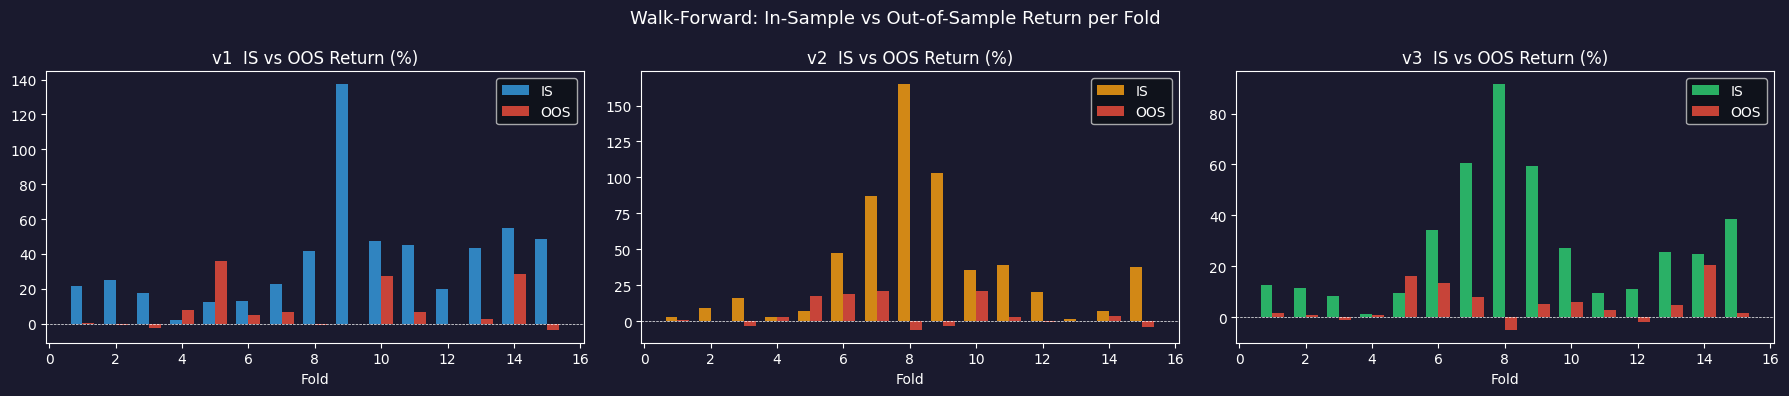

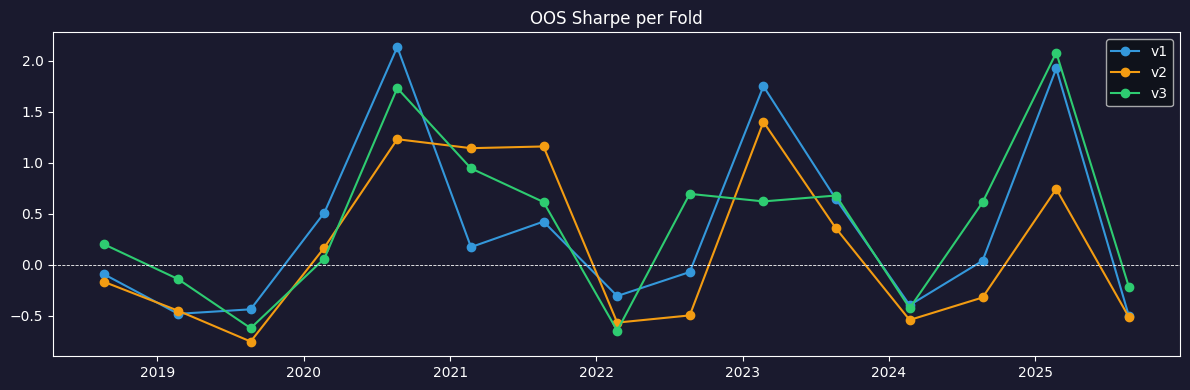


--- Param Stability (mean +/- std across folds) ---

  v1:


,mean,std,cv%
bb_window,17.40,4.64,26.7
bb_multiplier,1.59,0.32,20.1
bb_matype,1.27,1.03,81.5
kc_window,42.53,11.26,26.5
kc_multiplier,1.28,0.35,27.1
kc_atr_period,14.53,5.18,35.6
atr_period,15.40,5.08,33.0
atr_multiplier,2.69,0.64,23.6
low_stop_lookback,6.80,3.36,49.5
consecutive_neg_threshold,10.07,3.10,30.8



  v2:


,mean,std,cv%
bb_window,14.73,4.23,28.7
bb_multiplier,1.55,0.36,22.9
bb_matype,1.07,0.88,82.8
kc_window,39.67,11.85,29.9
kc_multiplier,1.20,0.41,34.1
kc_atr_period,14.33,3.27,22.8
atr_period,15.47,3.76,24.3
atr_multiplier,2.30,0.53,22.9
low_stop_lookback,10.07,4.93,49.0
consecutive_neg_threshold,10.67,3.15,29.6



  v3:


,mean,std,cv%
bb_window,15.93,5.97,37.5
bb_multiplier,1.11,0.38,34.1
bb_matype,0.87,1.19,137.0
kc_window,41.67,9.41,22.6
kc_multiplier,1.47,0.39,26.7
kc_atr_period,14.47,5.54,38.3
atr_period,11.40,4.47,39.2
atr_multiplier,2.70,0.46,17.0
low_stop_lookback,12.87,5.11,39.7
consecutive_neg_threshold,8.20,3.51,42.8



--- Recommended Params (median across WFV folds) ---
  v1: {'bb_window': 18, 'bb_multiplier': 1.6, 'bb_matype': 1, 'kc_window': 48, 'kc_multiplier': 1.2, 'kc_atr_period': 17, 'atr_period': 17, 'atr_multiplier': 2.6, 'low_stop_lookback': 7, 'consecutive_neg_threshold': 10, 'william_vix_period': 19, 'kama_period': 18, 'kama_fast': 4, 'kama_slow': 33, 'kama_slope_win': 5, 'flat_threshold_pct': 2.5}
  v2: {'bb_window': 14, 'bb_multiplier': 1.7, 'bb_matype': 1, 'kc_window': 46, 'kc_multiplier': 1.1, 'kc_atr_period': 15, 'atr_period': 17, 'atr_multiplier': 2.3, 'low_stop_lookback': 9, 'consecutive_neg_threshold': 10, 'william_vix_period': 20, 'kama_period': 13, 'kama_fast': 3, 'kama_slow': 37, 'kama_slope_win': 7, 'flat_threshold_pct': 2.5}
  v3: {'bb_window': 14, 'bb_multiplier': 1.0, 'bb_matype': 0, 'kc_window': 42, 'kc_multiplier': 1.5, 'kc_atr_period': 17, 'atr_period': 13, 'atr_multiplier': 2.4, 'low_stop_lookback': 13, 'consecutive_neg_threshold': 7, 'william_vix_period': 24, 'kama_pe

,folds,oos_ret_mean,oos_ret_pos%,oos_sortino_mean,oos_sharpe_mean,is_ret_mean,overfit_ratio
version,,,,,,,
v1,15,7.47,60.0,1.086,0.355,36.86,0.203
v2,15,4.63,60.0,0.815,0.160,38.72,0.120
v3,15,4.95,80.0,1.581,0.413,28.42,0.174



overfit_ratio: OOS/IS return -- closer to 1.0 = less overfit.


In [29]:
# ─── WFV Analysis ─────────────────────────────────────────────────────────────

COLORS_WFV = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

# 1. IS vs OOS return per fold
fig, axes = plt.subplots(1, len(WFV_VERSIONS),
                         figsize=(6 * len(WFV_VERSIONS), 4), sharey=False)
fig.patch.set_facecolor('#1a1a2e')
if len(WFV_VERSIONS) == 1:
    axes = [axes]

for ax, ver in zip(axes, WFV_VERSIONS):
    sub = wfv_df[wfv_df['version'] == ver].copy()
    x = sub['fold']
    ax.bar(x - 0.18, sub['is_return'],  width=0.36, color=COLORS_WFV[ver], alpha=0.85, label='IS')
    ax.bar(x + 0.18, sub['oos_return'], width=0.36, color='#e74c3c',        alpha=0.85, label='OOS')
    ax.axhline(0, color='white', lw=0.5, ls='--')
    ax.set_facecolor('#1a1a2e')
    ax.set_title(f'{ver}  IS vs OOS Return (%)', color='white')
    ax.tick_params(colors='white')
    [sp.set_edgecolor('white') for sp in ax.spines.values()]
    ax.legend(facecolor='#0d1117', labelcolor='white')
    ax.set_xlabel('Fold', color='white')

plt.suptitle('Walk-Forward: In-Sample vs Out-of-Sample Return per Fold',
             color='white', fontsize=13)
plt.tight_layout()
plt.show()

# 2. OOS Sharpe over time
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
for ver in WFV_VERSIONS:
    sub = wfv_df[wfv_df['version'] == ver].sort_values('fold')
    ax.plot(sub['test_start'], sub['oos_sharpe'],
            marker='o', color=COLORS_WFV[ver], label=ver, lw=1.5)
ax.axhline(0, color='white', lw=0.6, ls='--')
ax.set_title('OOS Sharpe per Fold', color='white')
ax.tick_params(colors='white')
[sp.set_edgecolor('white') for sp in ax.spines.values()]
ax.legend(facecolor='#0d1117', labelcolor='white')
plt.tight_layout()
plt.show()

# 3. Param stability
print('\n--- Param Stability (mean +/- std across folds) ---')
param_cols_wfv = [c for c in wfv_df.columns if c.startswith('p_')]
for ver in WFV_VERSIONS:
    sub = wfv_df[wfv_df['version'] == ver][param_cols_wfv]
    stats = sub.agg(['mean', 'std']).T
    stats.columns = ['mean', 'std']
    stats['cv%'] = (stats['std'] / stats['mean'].abs() * 100).round(1)
    stats.index = [c[2:] for c in stats.index]
    print(f'\n  {ver}:')
    display(stats.style.format({'mean': '{:.2f}', 'std': '{:.2f}', 'cv%': '{:.1f}'}))

# 4. Recommended params = median across folds
print('\n--- Recommended Params (median across WFV folds) ---')
INT_PARAMS = {
    'bb_window', 'bb_matype', 'kc_window', 'kc_atr_period',
    'atr_period', 'low_stop_lookback', 'consecutive_neg_threshold',
    'william_vix_period', 'kama_period', 'kama_fast', 'kama_slow', 'kama_slope_win',
}
wfv_best_params = {}
for ver in WFV_VERSIONS:
    sub = wfv_df[wfv_df['version'] == ver][param_cols_wfv]
    med = sub.median().to_dict()
    med = {k[2:]: (int(round(v)) if k[2:] in INT_PARAMS else round(v, 2))
           for k, v in med.items()}
    wfv_best_params[ver] = med
    print(f'  {ver}: {med}')

# 5. Summary
print('\n--- WFV Summary ---')
summary_wfv = []
for ver in WFV_VERSIONS:
    sub = wfv_df[wfv_df['version'] == ver]
    is_mean = sub['is_return'].mean()
    summary_wfv.append({
        'version':          ver,
        'folds':            len(sub),
        'oos_ret_mean':     round(sub['oos_return'].mean(), 2),
        'oos_ret_pos%':     round((sub['oos_return'] > 0).mean() * 100, 1),
        'oos_sortino_mean': round(sub['oos_sortino'].mean(), 3),
        'oos_sharpe_mean':  round(sub['oos_sharpe'].mean(), 3),
        'is_ret_mean':      round(is_mean, 2),
        'overfit_ratio':    round(sub['oos_return'].mean() / is_mean, 3)
                            if is_mean != 0 else float('nan'),
    })
display(pd.DataFrame(summary_wfv).set_index('version'))
print('\noverfit_ratio: OOS/IS return -- closer to 1.0 = less overfit.')


## 5. Select Best Params per Version

In [30]:
SELECTION = 'balanced'   # 'best_return' | 'best_sortino' | 'balanced'

def pick_best(study, selection=SELECTION):
    if selection == 'best_return':
        return max(study.best_trials, key=lambda t: t.values[0])
    if selection == 'best_sortino':
        return max(study.best_trials, key=lambda t: t.values[1])
    # balanced
    def score(t):
        return 0.4 * (t.values[0] + 100) / 200 + 0.6 * (t.values[1] + 10) / 20
    return max(study.best_trials, key=score)

best_trials = {ver: pick_best(studies[ver]) for ver in ['v1', 'v2', 'v3']}
best_params = {ver: t.params for ver, t in best_trials.items()}

summary_rows = []
for ver, trial in best_trials.items():
    row = {'Version': ver,
           'Trial #': trial.number,
           'Total Return (%)': round(trial.values[0], 2),
           'Sortino':          round(trial.values[1], 3)}
    row.update(trial.params)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Version')
print(f'Selection strategy: {SELECTION}')
display(summary_df)


Selection strategy: balanced


,Trial #,Total Return (%),Sortino,bb_window,bb_multiplier,bb_matype,kc_window,kc_multiplier,kc_atr_period,atr_period,atr_multiplier,low_stop_lookback,consecutive_neg_threshold,william_vix_period,kama_period,kama_fast,kama_slow,kama_slope_win,flat_threshold_pct
Version,,,,,,,,,,,,,,,,,,,
v1,985,491.11,1.049,11,1.1,1,53,1.3,6,6,2.6,4,12,29,10,5,37,5,2.9
v2,650,331.41,0.934,10,1.2,1,53,0.8,15,5,2.3,7,6,20,6,4,40,5,1.7
v3,826,152.98,0.708,11,1.3,1,45,1.3,17,6,2.4,15,15,18,13,4,40,14,1.3


In [31]:
# Extract all optimised parameters from `summary_df` (run after optimisation cell above)
_meta_cols = {'Trial #', 'Total Return (%)', 'Sortino'}
param_cols = [c for c in summary_df.columns if c not in _meta_cols]
all_params_by_version = summary_df[param_cols].to_dict('index')

import json
print('Tunable keys ({}):'.format(len(param_cols)))
print(param_cols)
print(json.dumps(all_params_by_version, indent=2, default=str))


Tunable keys (16):
['bb_window', 'bb_multiplier', 'bb_matype', 'kc_window', 'kc_multiplier', 'kc_atr_period', 'atr_period', 'atr_multiplier', 'low_stop_lookback', 'consecutive_neg_threshold', 'william_vix_period', 'kama_period', 'kama_fast', 'kama_slow', 'kama_slope_win', 'flat_threshold_pct']
{
  "v1": {
    "bb_window": 11,
    "bb_multiplier": 1.1,
    "bb_matype": 1,
    "kc_window": 53,
    "kc_multiplier": 1.3,
    "kc_atr_period": 6,
    "atr_period": 6,
    "atr_multiplier": 2.6,
    "low_stop_lookback": 4,
    "consecutive_neg_threshold": 12,
    "william_vix_period": 29,
    "kama_period": 10,
    "kama_fast": 5,
    "kama_slow": 37,
    "kama_slope_win": 5,
    "flat_threshold_pct": 2.9000000000000004
  },
  "v2": {
    "bb_window": 10,
    "bb_multiplier": 1.2000000000000002,
    "bb_matype": 1,
    "kc_window": 53,
    "kc_multiplier": 0.8,
    "kc_atr_period": 15,
    "atr_period": 5,
    "atr_multiplier": 2.3,
    "low_stop_lookback": 7,
    "consecutive_neg_threshold": 

In [32]:
summary_df

,Trial #,Total Return (%),Sortino,bb_window,bb_multiplier,bb_matype,kc_window,kc_multiplier,kc_atr_period,atr_period,atr_multiplier,low_stop_lookback,consecutive_neg_threshold,william_vix_period,kama_period,kama_fast,kama_slow,kama_slope_win,flat_threshold_pct
Version,,,,,,,,,,,,,,,,,,,
v1,985,491.11,1.049,11,1.1,1,53,1.3,6,6,2.6,4,12,29,10,5,37,5,2.9
v2,650,331.41,0.934,10,1.2,1,53,0.8,15,5,2.3,7,6,20,6,4,40,5,1.7
v3,826,152.98,0.708,11,1.3,1,45,1.3,17,6,2.4,15,15,18,13,4,40,14,1.3


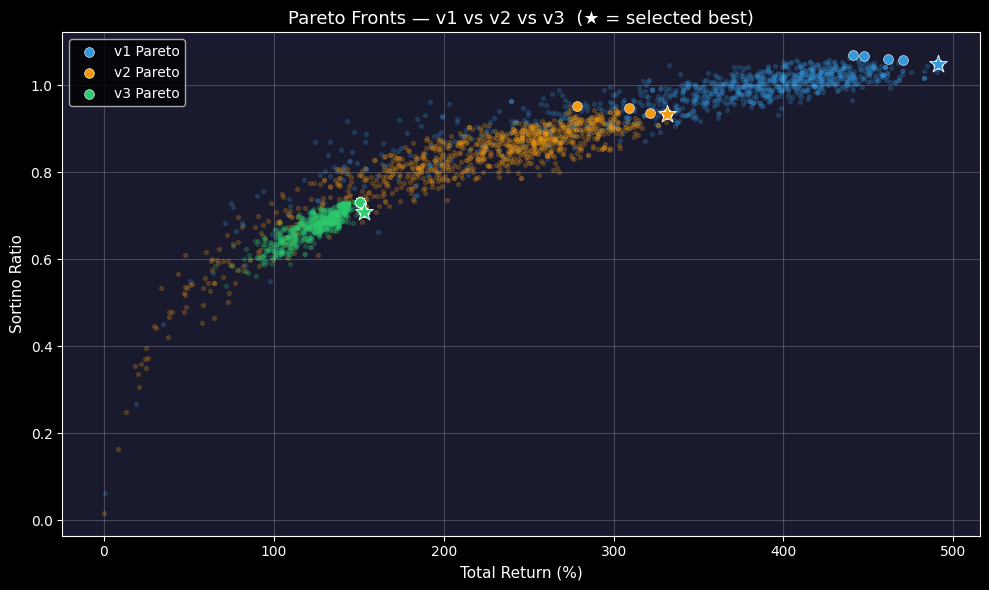

In [33]:
# ── Pareto fronts of all 3 versions on one chart ─────────────────────────────
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#1a1a2e')

for ver, study in studies.items():
    col = COLORS[ver]
    # background: all trials
    all_vals = [(t.values[0], t.values[1]) for t in study.trials
                if t.values and t.values[0] > -900]
    if all_vals:
        ax.scatter(*zip(*all_vals), c=col, s=8, alpha=0.2)
    # Pareto front
    pf_vals = [(t.values[0], t.values[1]) for t in study.best_trials]
    ax.scatter(*zip(*pf_vals), c=col, s=50, zorder=5,
               edgecolors='white', linewidths=0.4, label=f'{ver} Pareto')
    # best point
    bt = best_trials[ver]
    ax.scatter(bt.values[0], bt.values[1], c=col, s=180, marker='*',
               zorder=6, edgecolors='white', linewidths=0.6)

ax.set_xlabel('Total Return (%)', fontsize=11)
ax.set_ylabel('Sortino Ratio',    fontsize=11)
ax.set_title('Pareto Fronts — v1 vs v2 vs v3  (★ = selected best)', fontsize=13)
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.2); ax.xaxis.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()


## 6. Final Backtest — Optimised v1 vs v2 vs v3

In [34]:
portfolios = {}

for ver in ['v1', 'v2', 'v3']:
    p  = best_params[ver]
    print(f'Running optimised {ver} ...')
    entries = compute_signals(
        close, high, low, volume,
        bb_window                = p['bb_window'],
        bb_multiplier            = p['bb_multiplier'],
        bb_matype                = p['bb_matype'],
        kc_window                = p['kc_window'],
        kc_multiplier            = p['kc_multiplier'],
        kc_atr_period            = p['kc_atr_period'],
        donichan_window          = p.get('donichan_window', 10),
        osc_smoothing_period     = p.get('osc_smoothing_period', 5),
        entry_version            = ver,
        consecutive_neg_threshold= p.get('consecutive_neg_threshold', 7),
        william_vix_period       = p.get('william_vix_period',        20),
        # avwap_window             = p.get('avwap_window',             200),
        use_kama_slope           = True,
        kama_period              = p.get('kama_period',              10),
        kama_fast                = p.get('kama_fast',                 2),
        kama_slow                = p.get('kama_slow',                30),
        kama_slope_win           = p.get('kama_slope_win',            5),
        flat_threshold_pct       = p.get('flat_threshold_pct',        1.0),
        use_near_low_filter      = p.get('use_near_low_filter',        False),
        near_low_window          = p.get('near_low_window',            3),
        near_low_max_pct         = p.get('near_low_max_pct',          12.0),
    )
    exits, sl_stop_df = compute_exits(
        close, high, low,
        atr_multiplier   = p['atr_multiplier'],
        low_stop_lookback= p.get('low_stop_lookback', 5),
        entries=entries,
    )
    early_exits = early_exit_signal(close, low, entries, window=5, pct=0.05)
    pf = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits | early_exits,
        freq='1d', group_by=['symbol'],
        cash_sharing=False, sl_stop=sl_stop_df,
    )
    portfolios[ver] = pf
    n_sig = int(entries.sum().sum())
    print(f'  signals={n_sig:,}  trades={int(pf.trades.count().sum()):,}')

print('\nAll done.')


Running optimised v1 ...
  signals=159,037  trades=15,623
Running optimised v2 ...
  signals=57,230  trades=15,371
Running optimised v3 ...
  signals=14,194  trades=11,776

All done.


## 6b. Exit Strategy A/B — ATR Trailing vs Chandelier

Goal: stop getting shaken out of strong uptrends. The current exit trails a
fixed-multiple ATR off **close**; the Chandelier trails off the **highest-high /
lowest-close average since entry**, so a single weak close no longer trips it.

Everything else (entries, swing-low initial `sl_stop`, early-exit, max-hold) is
held identical — only the trailing mechanism changes — so the comparison is clean.

Tune `CHAND_LENGTH` / `CHAND_MULT` below. Classic defaults: length=22, mult=3.0.
The winner per version is stored in `best_exit_by_version` and the chosen
portfolios in `portfolios_final`.


In [35]:
# ── Build Chandelier portfolios, mirroring Section 6 exactly ──────────────────
CHAND_LENGTH = 5     # ATR + highest/lowest lookback for the chandelier
CHAND_MULT   = 2.2    # ATR multiplier (wider = more room to run)
CHOICE_METRIC = 'sharpe_mean'   # ranking metric: 'sortino_mean'|'sharpe_mean'|'total_ret_mean'

def _build_entries(ver):
    p = best_params[ver]
    return compute_signals(
        close, high, low, volume,
        bb_window=p['bb_window'], bb_multiplier=p['bb_multiplier'], bb_matype=p['bb_matype'],
        kc_window=p['kc_window'], kc_multiplier=p['kc_multiplier'], kc_atr_period=p['kc_atr_period'],
        donichan_window=p.get('donichan_window', 10),
        osc_smoothing_period=p.get('osc_smoothing_period', 5),
        entry_version=ver,
        consecutive_neg_threshold=p.get('consecutive_neg_threshold', 7),
        william_vix_period=p.get('william_vix_period', 20),
        use_kama_slope=True,
        kama_period=p.get('kama_period', 10), kama_fast=p.get('kama_fast', 2),
        kama_slow=p.get('kama_slow', 30), kama_slope_win=p.get('kama_slope_win', 5),
        flat_threshold_pct=p.get('flat_threshold_pct', 1.0),
        use_near_low_filter=p.get('use_near_low_filter', False),
        near_low_window=p.get('near_low_window', 3),
        near_low_max_pct=p.get('near_low_max_pct', 12.0),
    )

portfolios_chand = {}
for ver in ['v1', 'v2', 'v3']:
    p = best_params[ver]
    print(f'Running Chandelier {ver} ...')
    entries = _build_entries(ver)
    exits_c, sl_c = compute_exits_chandelier(
        close, high, low,
        length=CHAND_LENGTH, multiplier=CHAND_MULT,
        low_stop_lookback=p.get('low_stop_lookback', 5),
        entries=entries,
    )
    early_exits = early_exit_signal(close, low, entries, window=5, pct=0.05)
    pf = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits_c | early_exits,
        freq='1d', group_by=['symbol'],
        cash_sharing=False, sl_stop=sl_c,
    )
    portfolios_chand[ver] = pf
    print(f'  trades={int(pf.trades.count().sum()):,}')


# ── Metrics + winner selection ────────────────────────────────────────────────
def _scalar_mean(x):
    """Mean across symbols / groups when vbt returns a Series."""
    s = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    return float(s.mean()) if len(s) else float('nan')


def _exit_stats(pf):
    sh = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    so = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    tr = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
    dd = pf.max_drawdown().replace([np.inf, -np.inf], np.nan).dropna()
    wins = pf.trades.records_readable
    pnl_col = 'PnL' if 'PnL' in wins.columns else None
    win_rate = float((wins[pnl_col] > 0).mean()) if pnl_col and len(wins) else float('nan')
    avg_hold = _scalar_mean(pf.trades.duration.mean()) if pf.trades.count().sum() else float('nan')
    return {
        'sharpe_mean':    round(_scalar_mean(sh), 3),
        'sortino_mean':   round(_scalar_mean(so), 3),
        'total_ret_mean': round(_scalar_mean(tr) * 100, 2),
        'win_rate%':      round(win_rate * 100, 1),
        'max_dd_mean%':   round(_scalar_mean(dd) * 100, 2),
        'avg_hold_bars':  round(avg_hold, 1),
        'trades':         int(pf.trades.count().sum()),
    }

rows = []
best_exit_by_version = {}
portfolios_final = {}
for ver in ['v1', 'v2', 'v3']:
    s_atr   = _exit_stats(portfolios[ver]);        s_atr['exit'] = 'ATR trailing'; s_atr['version'] = ver
    s_chand = _exit_stats(portfolios_chand[ver]);  s_chand['exit'] = 'Chandelier';  s_chand['version'] = ver
    rows.append(s_atr); rows.append(s_chand)
    pick_chand = s_chand[CHOICE_METRIC] >= s_atr[CHOICE_METRIC]
    best_exit_by_version[ver] = 'Chandelier' if pick_chand else 'ATR trailing'
    portfolios_final[ver]     = portfolios_chand[ver] if pick_chand else portfolios[ver]

cmp_df = pd.DataFrame(rows).set_index(['version', 'exit'])
print(f'\nRanking metric: {CHOICE_METRIC}  (higher = better)')
display(cmp_df)
print('\nWinner per version:')
for ver in ['v1', 'v2', 'v3']:
    w = best_exit_by_version[ver]
    delta = (cmp_df.loc[(ver, "Chandelier"), CHOICE_METRIC]
             - cmp_df.loc[(ver, "ATR trailing"), CHOICE_METRIC])
    print(f'  {ver}: {w:<13}  (Chandelier - ATR {CHOICE_METRIC} = {delta:+.3f})')
print('\nportfolios_final holds the chosen exit per version.')


Running Chandelier v1 ...
  trades=15,700
Running Chandelier v2 ...
  trades=14,367
Running Chandelier v3 ...
  trades=11,507

Ranking metric: sharpe_mean  (higher = better)


sharpe_mean  sortino_mean  total_ret_mean  win_rate%  \
version exit                                                                 
v1      ATR trailing        0.721         1.146          517.61       37.1   
        Chandelier          0.704         1.117          500.85       37.1   
v2      ATR trailing        0.655         1.046          371.23       37.7   
        Chandelier          0.631         1.001          358.73       37.1   
v3      ATR trailing        0.491         0.772          175.96       36.1   
        Chandelier          0.474         0.742          167.78       35.7   

                      max_dd_mean%  avg_hold_bars  trades  
version exit                                               
v1      ATR trailing        -47.10           19.2   15623  
        Chandelier          -47.61           19.2   15700  
v2      ATR trailing        -46.77           18.1   15371  
        Chandelier          -48.10           20.3   14367  
v3      ATR trailing        -44.43           16.2   11776  
        Chandelier          -45.03           16.9   11507


Winner per version:
  v1: ATR trailing   (Chandelier - ATR sharpe_mean = -0.017)
  v2: ATR trailing   (Chandelier - ATR sharpe_mean = -0.024)
  v3: ATR trailing   (Chandelier - ATR sharpe_mean = -0.017)

portfolios_final holds the chosen exit per version.


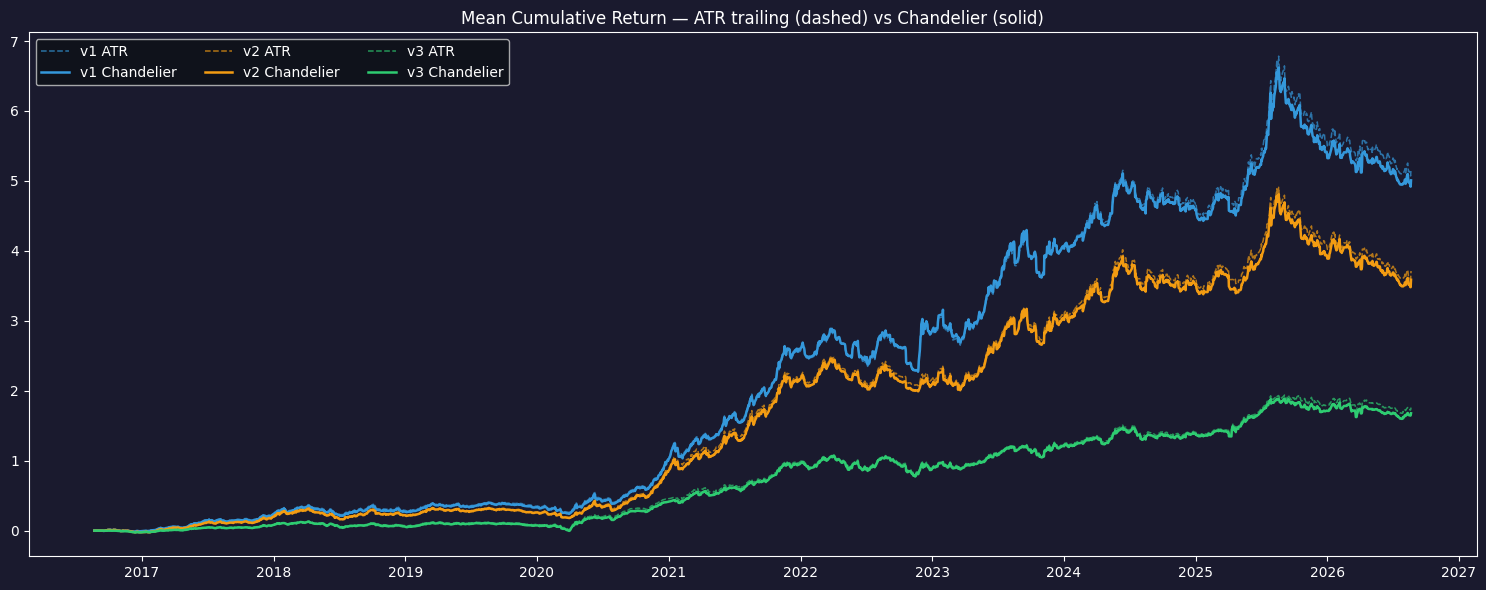

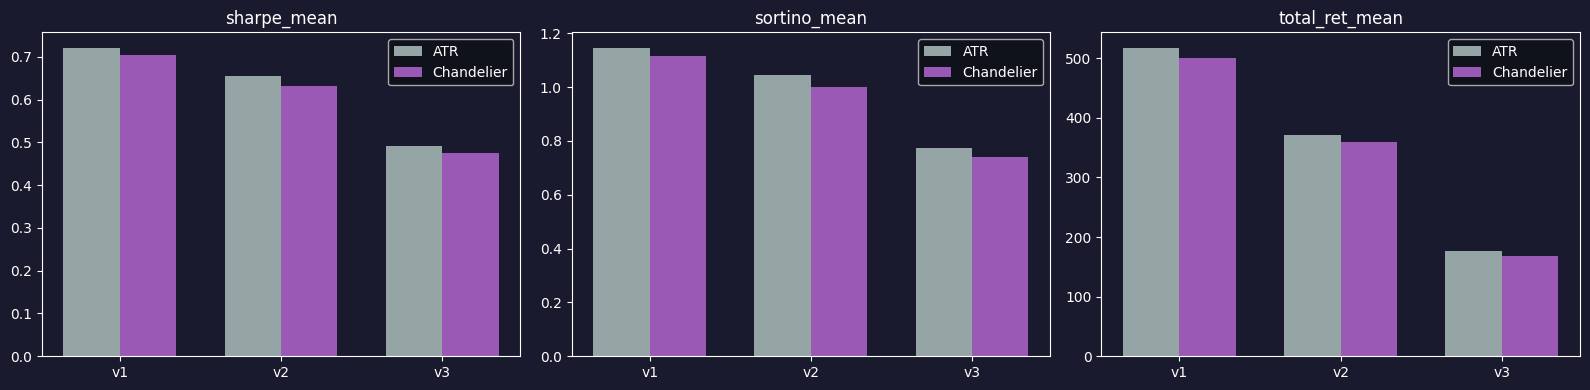

KeyError: 'AAA'

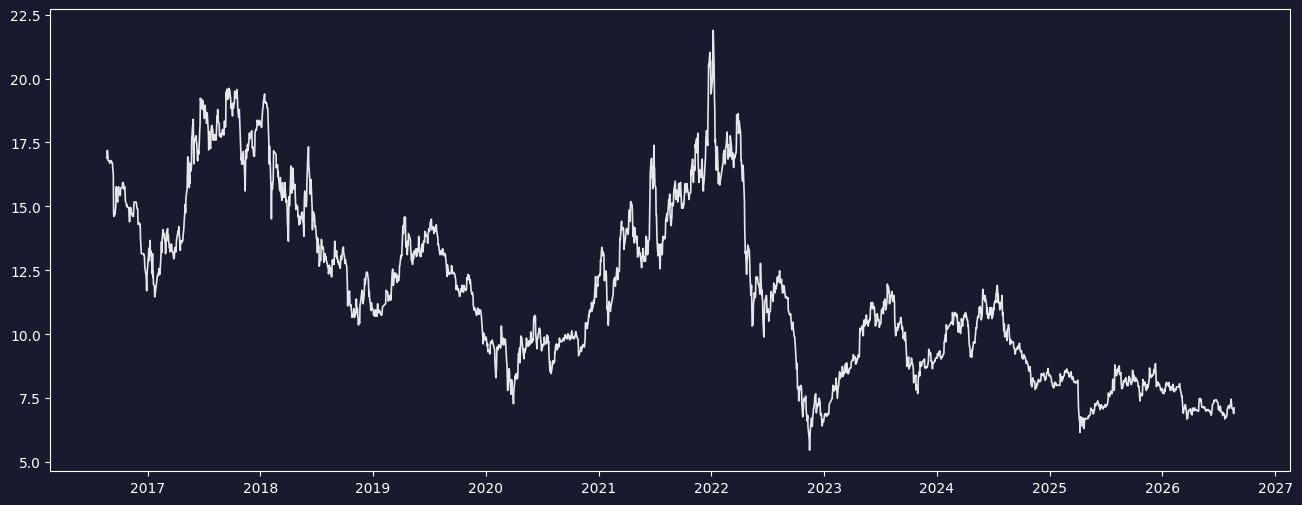

In [36]:
# ── Visualise the difference ──────────────────────────────────────────────────
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

# 1. Equity curves: ATR (dashed) vs Chandelier (solid)
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_facecolor('#1a1a2e'); fig.patch.set_facecolor('#1a1a2e')
for ver in ['v1', 'v2', 'v3']:
    a = portfolios[ver].cumulative_returns().mean(axis=1)
    c = portfolios_chand[ver].cumulative_returns().mean(axis=1)
    ax.plot(a.index, a.values, color=COLORS[ver], lw=1.1, ls='--', alpha=0.7,
            label=f'{ver} ATR')
    ax.plot(c.index, c.values, color=COLORS[ver], lw=1.8,
            label=f'{ver} Chandelier')
ax.set_title('Mean Cumulative Return — ATR trailing (dashed) vs Chandelier (solid)',
             color='white')
ax.tick_params(colors='white'); [sp.set_edgecolor('white') for sp in ax.spines.values()]
ax.legend(facecolor='#0d1117', labelcolor='white', ncol=3)
plt.tight_layout(); plt.show()

# 2. Grouped bars: Sharpe / Sortino / Total Ret
metrics = ['sharpe_mean', 'sortino_mean', 'total_ret_mean']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor('#1a1a2e')
x = np.arange(3); w = 0.35
for ax, met in zip(axes, metrics):
    atr_vals   = [cmp_df.loc[(v, 'ATR trailing'), met] for v in ['v1', 'v2', 'v3']]
    chand_vals = [cmp_df.loc[(v, 'Chandelier'),   met] for v in ['v1', 'v2', 'v3']]
    ax.bar(x - w/2, atr_vals,   w, color='#95a5a6', label='ATR')
    ax.bar(x + w/2, chand_vals, w, color='#9b59b6', label='Chandelier')
    ax.set_facecolor('#1a1a2e'); ax.set_title(met, color='white')
    ax.set_xticks(x); ax.set_xticklabels(['v1', 'v2', 'v3'], color='white')
    ax.tick_params(colors='white'); [sp.set_edgecolor('white') for sp in ax.spines.values()]
    ax.legend(facecolor='#0d1117', labelcolor='white')
plt.tight_layout(); plt.show()

# 3. Single-symbol inspection — see the trail hold an uptrend
INSPECT_VER = 'v1'
INSPECT_SYM = close.columns[0]   # change to any symbol, e.g. 'VCB'
p = best_params[INSPECT_VER]
entries_i = _build_entries(INSPECT_VER)
_, _, chand_line, chand_dir = compute_exits_chandelier(
    close, high, low, length=CHAND_LENGTH, multiplier=CHAND_MULT,
    entries=entries_i, return_line=True,
)
# Current ATR trail line for the same symbol
atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
    high, low, close, timeperiod=p.get('atr_period', 10)).real
ATRTrailing = vbt.IndicatorFactory(
    input_names=['close', 'atr'], param_names=['atr_multiplier'],
    output_names=['atr_trailing']).from_apply_func(atr_trailing_nb)
atr_line = ATRTrailing.run(close, atr_raw, atr_multiplier=p['atr_multiplier']).atr_trailing

sym = INSPECT_SYM
fig, ax = plt.subplots(figsize=(16, 6))
ax.set_facecolor('#1a1a2e'); fig.patch.set_facecolor('#1a1a2e')
ax.plot(close.index, close[sym].values, color='#e5e7eb', lw=1.2, label='Close')
ax.plot(atr_line.index, atr_line[sym].values, color='#95a5a6', lw=1.0, ls='--',
        label='ATR trail')
cl = chand_line[sym]; cd = chand_dir[sym]
ax.plot(cl.index, cl.where(cd > 0).values, color='#2ecc71', lw=1.4, label='Chandelier (long)')
ax.plot(cl.index, cl.where(cd < 0).values, color='#e74c3c', lw=1.4, label='Chandelier (short)')
ent = entries_i[sym]
ax.scatter(ent.index[ent.values], close[sym].values[ent.values],
           marker='^', color='#22c55e', s=60, zorder=5, label='Entry')
ax.set_title(f'{sym} ({INSPECT_VER}) — ATR trail vs Chandelier', color='white')
ax.tick_params(colors='white'); [sp.set_edgecolor('white') for sp in ax.spines.values()]
ax.legend(facecolor='#0d1117', labelcolor='white')
plt.tight_layout(); plt.show()


## 7. Comparison — Stats Table

In [ ]:
def version_stats(ver, pf):
    s = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    return {
        'Version':          ver,
        'Sharpe mean':      round(s.mean(), 3),
        'Sharpe median':    round(s.median(), 3),
        'Sharpe > 0':       f'{(s > 0).sum()}/{len(s)}',
        'Sharpe > 1':       f'{(s > 1).sum()}/{len(s)}',
        'Sortino mean':     round(pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Calmar mean':      round(pf.calmar_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Total Ret mean':   f'{pf.total_return().mean():.1%}',
        'Total Ret median': f'{pf.total_return().median():.1%}',
        'Max DD mean':      f'{pf.max_drawdown().mean():.1%}',
        'Max DD worst':     f'{pf.max_drawdown().min():.1%}',
        'N Trades':         int(pf.trades.count().sum()),
        'Avg Trade Ret':    f'{pd.Series(pf.trades.returns.mean()).mean():.2%}',
        'Win Rate':         f'{pf.trades.win_rate().mean():.1%}',
        'Profit Factor':    round(pf.trades.profit_factor().mean(), 3),
    }

rows = [version_stats(ver, pf) for ver, pf in portfolios.items()]
# also add baseline
rows.insert(0, version_stats('baseline (v3 default)', pf_base))

comp_df = pd.DataFrame(rows).set_index('Version')
print('=== VERSION COMPARISON ===')
display(comp_df.T)


=== VERSION COMPARISON ===


Version,baseline (v3 default),v1,v2,v3
Sharpe mean,0.437,0.738,0.652,0.515
Sharpe median,0.472,0.763,0.63,0.5
Sharpe > 0,175/197,190/197,188/197,184/197
Sharpe > 1,10/197,47/197,38/197,17/197
Sortino mean,0.686,1.168,1.034,0.81
Calmar mean,0.245,0.547,0.46,0.323
Total Ret mean,114.5%,530.4%,347.8%,178.0%
Total Ret median,77.0%,282.7%,167.7%,93.3%
Max DD mean,-45.3%,-47.2%,-45.5%,-43.6%
Max DD worst,-75.1%,-94.4%,-93.3%,-76.2%


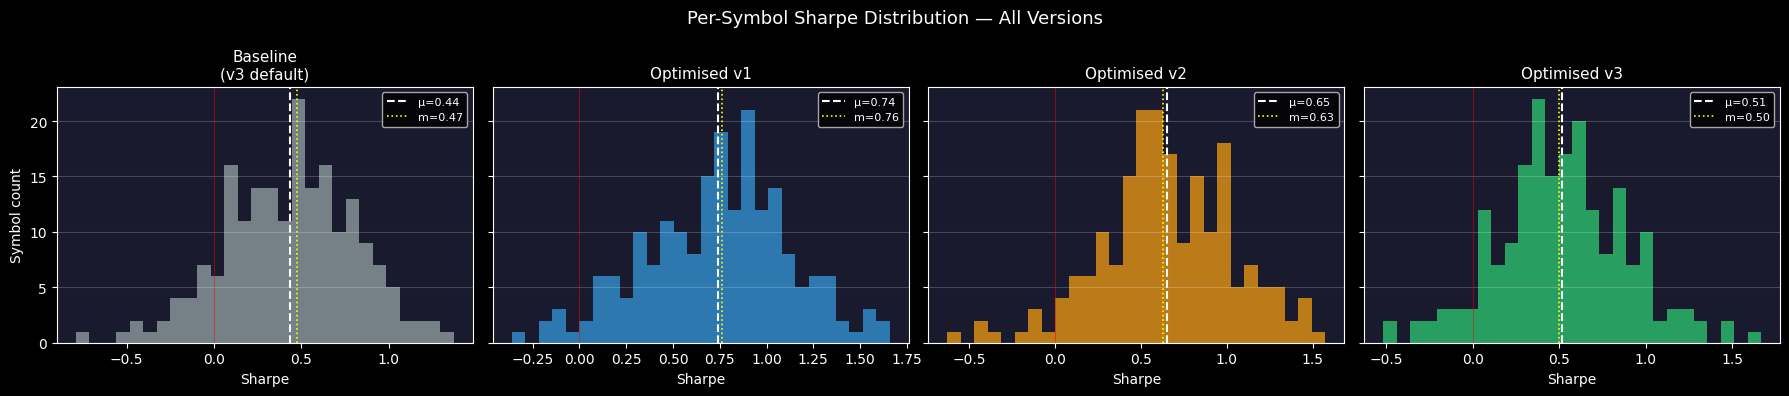

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

entries_list = [('Baseline\n(v3 default)', pf_base, '#95a5a6')] + [
    (f'Optimised {ver}', portfolios[ver], COLORS[ver])
    for ver in ['v1', 'v2', 'v3']
]

for ax, (name, pf, col) in zip(axes, entries_list):
    sv = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    ax.set_facecolor('#1a1a2e')
    ax.hist(sv, bins=28, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(sv.mean(),   color='white',  lw=1.5, ls='--',
               label=f'μ={sv.mean():.2f}')
    ax.axvline(sv.median(), color='yellow', lw=1.2, ls=':',
               label=f'm={sv.median():.2f}')
    ax.axvline(0, color='red', lw=0.7, alpha=0.5)
    ax.set_title(name, fontsize=11); ax.set_xlabel('Sharpe')
    ax.legend(fontsize=8); ax.yaxis.grid(True, alpha=0.2)

axes[0].set_ylabel('Symbol count')
fig.suptitle('Per-Symbol Sharpe Distribution — All Versions', fontsize=13)
fig.tight_layout(); plt.show()


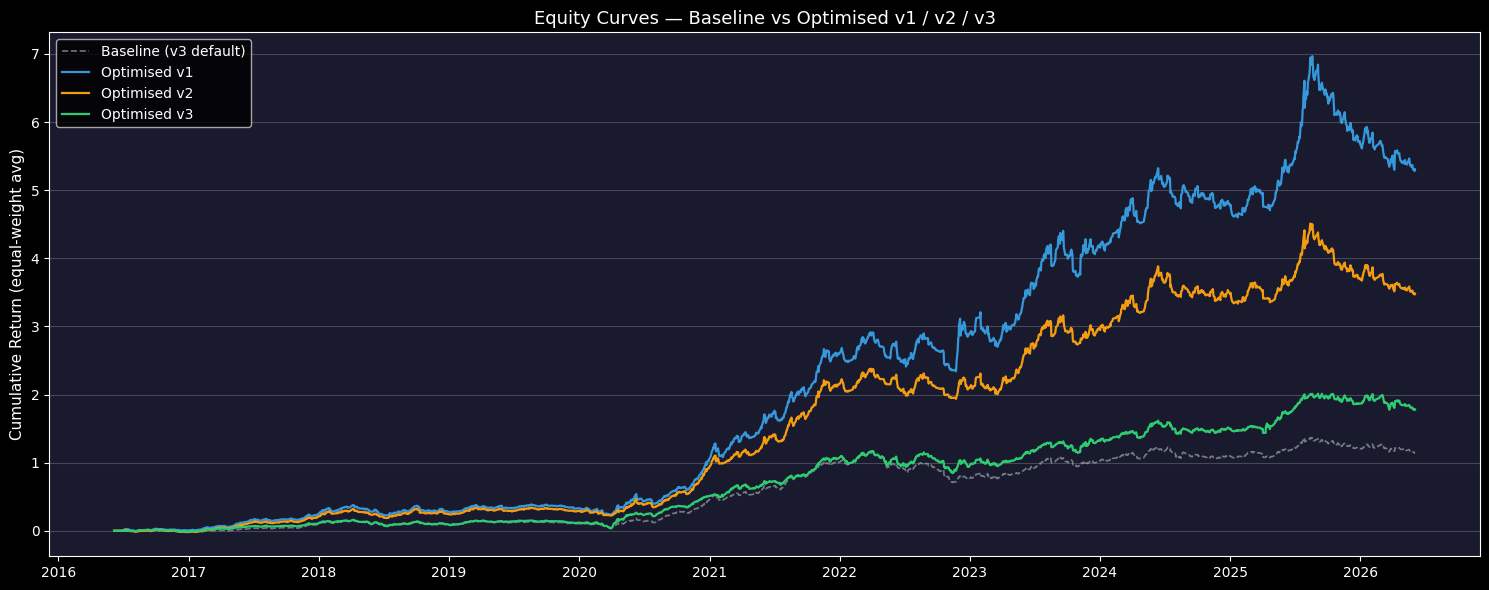

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_facecolor('#1a1a2e')

ax.plot(*zip(*[(d, v) for d, v in zip(
    pf_base.cumulative_returns().mean(axis=1).index,
    pf_base.cumulative_returns().mean(axis=1).values
)]), color='#95a5a6', lw=1.2, ls='--', label='Baseline (v3 default)', alpha=0.7)

for ver, pf in portfolios.items():
    cum = pf.cumulative_returns().mean(axis=1)
    ax.plot(cum.index, cum.values, label=f'Optimised {ver}',
            color=COLORS[ver], lw=1.6)

ax.set_ylabel('Cumulative Return (equal-weight avg)', fontsize=11)
ax.set_title('Equity Curves — Baseline vs Optimised v1 / v2 / v3', fontsize=13)
ax.legend(fontsize=10); ax.yaxis.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout(); plt.show()


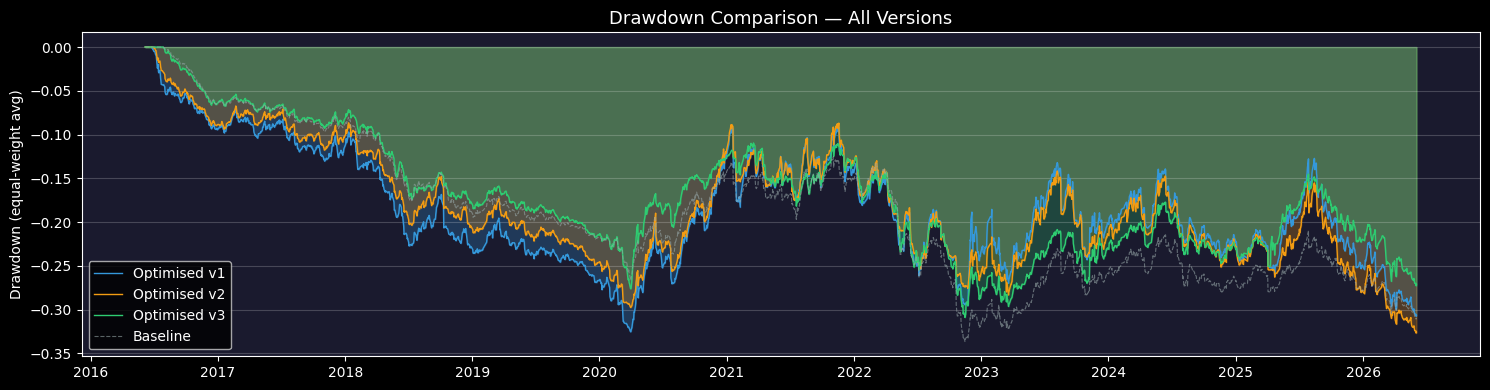

In [ ]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.set_facecolor('#1a1a2e')

for ver, pf in portfolios.items():
    dd = pf.drawdown().mean(axis=1)
    ax.fill_between(dd.index, dd.values, 0,
                    alpha=0.25, color=COLORS[ver])
    ax.plot(dd.index, dd.values, color=COLORS[ver], lw=1.0, label=f'Optimised {ver}')

# baseline
dd_base = pf_base.drawdown().mean(axis=1)
ax.plot(dd_base.index, dd_base.values, color='#95a5a6', lw=0.8, ls='--',
        alpha=0.6, label='Baseline')

ax.set_ylabel('Drawdown (equal-weight avg)')
ax.set_title('Drawdown Comparison — All Versions', fontsize=13)
ax.legend(fontsize=10); ax.yaxis.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout(); plt.show()


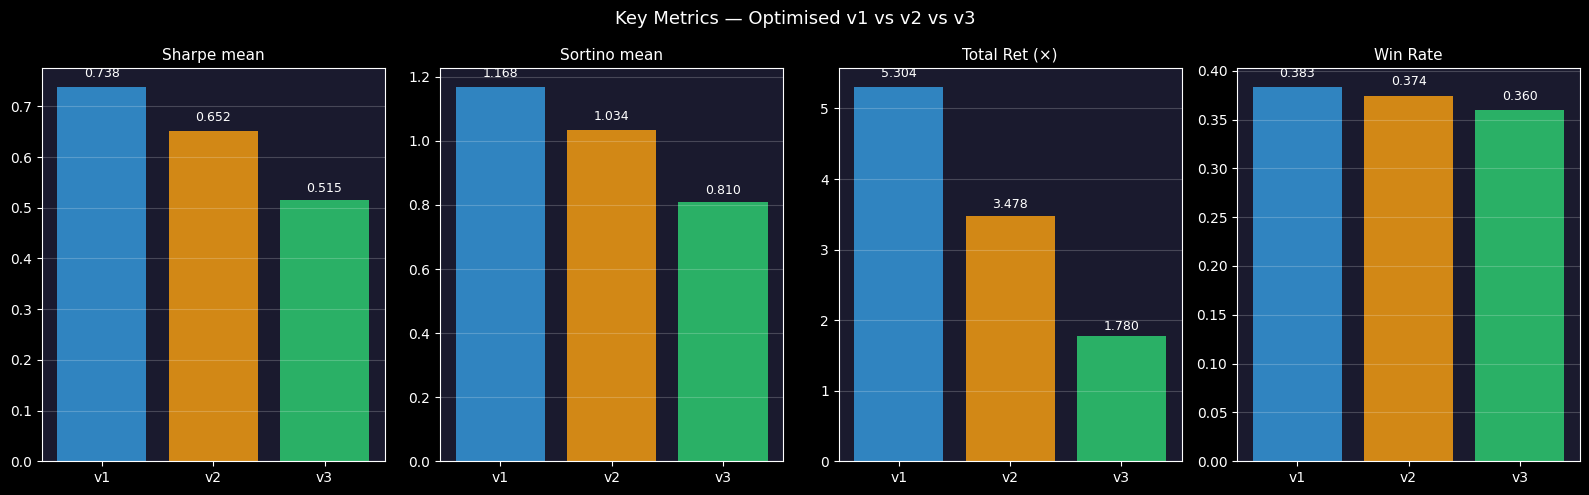

In [ ]:
# ── grouped bar chart: Sharpe mean, Sortino mean, Total Ret mean ──────────────
versions  = ['v1', 'v2', 'v3']
metrics   = {
    'Sharpe mean':  [portfolios[v].sharpe_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
                     for v in versions],
    'Sortino mean': [portfolios[v].sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
                     for v in versions],
    'Total Ret (×)': [portfolios[v].total_return().mean() for v in versions],
    'Win Rate':     [portfolios[v].trades.win_rate().mean() for v in versions],
}

x   = np.arange(len(versions))
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, vals) in zip(axes, metrics.items()):
    colors = [COLORS[v] for v in versions]
    bars   = ax.bar(versions, vals, color=colors, edgecolor='none', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + abs(val) * 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(metric, fontsize=11)
    ax.axhline(0, color='white', lw=0.6, alpha=0.5)
    ax.yaxis.grid(True, alpha=0.2)
    ax.set_facecolor('#1a1a2e')

fig.suptitle('Key Metrics — Optimised v1 vs v2 vs v3', fontsize=13)
fig.tight_layout(); plt.show()


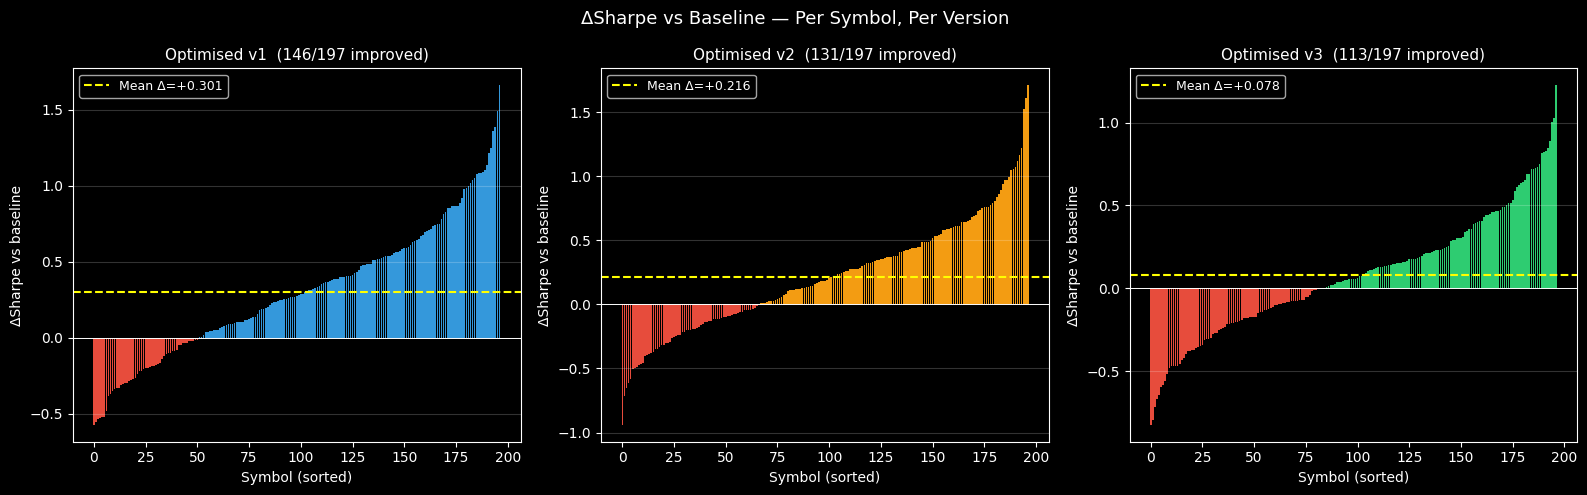

In [ ]:
# ── ΔSharpe vs baseline for each version ─────────────────────────────────────
sharpe_base_sym = pf_base.sharpe_ratio().replace([np.inf,-np.inf], np.nan)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ver in zip(axes, ['v1', 'v2', 'v3']):
    delta = (portfolios[ver].sharpe_ratio().replace([np.inf,-np.inf], np.nan)
             - sharpe_base_sym).dropna().sort_values()
    bar_colors = [COLORS[ver] if v >= 0 else '#e74c3c' for v in delta]
    ax.bar(range(len(delta)), delta.values, color=bar_colors, edgecolor='none')
    ax.axhline(0, color='white', lw=0.7)
    ax.axhline(delta.mean(), color='yellow', lw=1.5, ls='--',
               label=f'Mean Δ={delta.mean():+.3f}')
    improved = (delta > 0).sum()
    ax.set_title(f'Optimised {ver}  ({improved}/{len(delta)} improved)', fontsize=11)
    ax.set_xlabel('Symbol (sorted)'); ax.set_ylabel('ΔSharpe vs baseline')
    ax.legend(fontsize=9); ax.yaxis.grid(True, alpha=0.2)

fig.suptitle('ΔSharpe vs Baseline — Per Symbol, Per Version', fontsize=13)
fig.tight_layout(); plt.show()


In [ ]:
# ── final scorecard ───────────────────────────────────────────────────────────
print('=' * 62)
print('  FINAL SCORECARD — OPTIMISED v1 / v2 / v3')
print('=' * 62)
print(f'  {"Version":<12}  {"Sharpe μ":>9}  {"Sortino μ":>10}  {"Total Ret μ":>12}  {"Win Rate":>9}')
print('  ' + '-' * 58)

scores = []
for ver, pf in portfolios.items():
    sh = pf.sharpe_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
    so = pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
    tr = pf.total_return().mean()
    wr = pf.trades.win_rate().mean()
    scores.append((ver, sh, so, tr, wr))
    print(f'  {ver:<12}  {sh:>9.3f}  {so:>10.3f}  {tr:>12.1%}  {wr:>9.1%}')

print('=' * 62)
best_ver = max(scores, key=lambda x: x[1])
print(f'\n  Best Sharpe  → {best_ver[0]}  ({best_ver[1]:.3f})')
best_ret = max(scores, key=lambda x: x[3])
print(f'  Best Return  → {best_ret[0]}  ({best_ret[3]:.1%})')
best_so  = max(scores, key=lambda x: x[2])
print(f'  Best Sortino → {best_so[0]}  ({best_so[2]:.3f})')


  FINAL SCORECARD — OPTIMISED v1 / v2 / v3
  Version        Sharpe μ   Sortino μ   Total Ret μ   Win Rate
  ----------------------------------------------------------
  v1                0.738       1.168        530.4%      38.3%
  v2                0.652       1.034        347.8%      37.4%
  v3                0.515       0.810        178.0%      36.0%

  Best Sharpe  → v1  (0.738)
  Best Return  → v1  (530.4%)
  Best Sortino → v1  (1.168)


## 8. MFE / MAE Analysis

**MFE** (Maximum Favorable Excursion) = highest unrealised gain during a trade.
**MAE** (Maximum Adverse Excursion) = worst unrealised drawdown during a trade.

Key questions:
- Are stops too tight? (high MAE on winners)
- Are targets too conservative? (high MFE on losers)
- What fraction of available profit is captured? (trade efficiency)
- What is the edge ratio? (avg winner MFE / avg loser MAE)

In [ ]:
def compute_mfe_mae(pf, high_df, low_df, sym_set):
    rec = pf.trades.records_readable.copy()
    price_index = high_df.index
    use_bar_idx = 'Entry Index' in rec.columns
    ep_col = next((c for c in ('Avg Entry Price', 'Entry Price') if c in rec.columns), None)
    if ep_col is None:
        raise KeyError(f'No entry price column; got {list(rec.columns)}')

    def _sym(col):
        if isinstance(col, tuple):
            return next((v for v in col if v in sym_set), None)
        return col if col in sym_set else None

    def _ts_to_i(ts):
        ts = pd.Timestamp(ts)
        try:
            loc = price_index.get_loc(ts)
        except KeyError:
            loc = price_index.get_indexer([ts], method='nearest')[0]
            return int(loc)
        if isinstance(loc, slice):
            return loc.start
        if isinstance(loc, np.ndarray):
            return int(loc[0])
        return int(loc)

    rec['_sym'] = rec['Column'].apply(_sym)

    mfe_list, mae_list = [], []
    for _, row in rec.iterrows():
        sym = row['_sym']
        if sym is None or sym not in high_df.columns:
            mfe_list.append(float('nan')); mae_list.append(float('nan'))
            continue
        if use_bar_idx:
            ei, xi = int(row['Entry Index']), int(row['Exit Index'])
        else:
            ei = _ts_to_i(row['Entry Timestamp'])
            xi = _ts_to_i(row['Exit Timestamp'])
        ep = row[ep_col]
        h = high_df[sym].iloc[ei : xi + 1].max()
        l = low_df[sym].iloc[ei : xi + 1].min()
        mfe_list.append((h - ep) / ep * 100)
        mae_list.append((ep - l) / ep * 100)

    rec['MFE%']       = mfe_list
    rec['MAE%']       = mae_list
    rec['Return%']    = rec['Return'] * 100
    rec['Winner']     = rec['Return'] > 0
    rec['Efficiency'] = (rec['Return%'] / rec['MFE%'].clip(lower=0.001)).clip(0, 1)
    return rec

close_syms_set = set(close.columns)
mfe_mae = {ver: compute_mfe_mae(pf, high, low, close_syms_set)
           for ver, pf in portfolios.items()}

print(f"{'Ver':<5} {'N':>5}  {'MFE(W)':>8}  {'MAE(W)':>8}  {'MFE(L)':>8}  {'MAE(L)':>8}  {'Eff(W)':>8}")
print('-' * 62)
for ver, df in mfe_mae.items():
    w = df[df['Winner']].dropna(subset=['MFE%', 'MAE%'])
    l = df[~df['Winner']].dropna(subset=['MFE%', 'MAE%'])
    print(f"{ver:<5} {len(df):>5}  "
          f"{w['MFE%'].mean():>7.1f}%  {w['MAE%'].mean():>7.1f}%  "
          f"{l['MFE%'].mean():>7.1f}%  {l['MAE%'].mean():>7.1f}%  "
          f"{w['Efficiency'].median():>7.0%}")


Ver       N    MFE(W)    MAE(W)    MFE(L)    MAE(L)    Eff(W)
--------------------------------------------------------------
v1    15215     26.5%      3.7%      3.8%      5.9%      45%
v2    13774     24.8%      3.4%      3.9%      6.0%      43%
v3    11574     21.9%      3.2%      3.8%      5.9%      53%


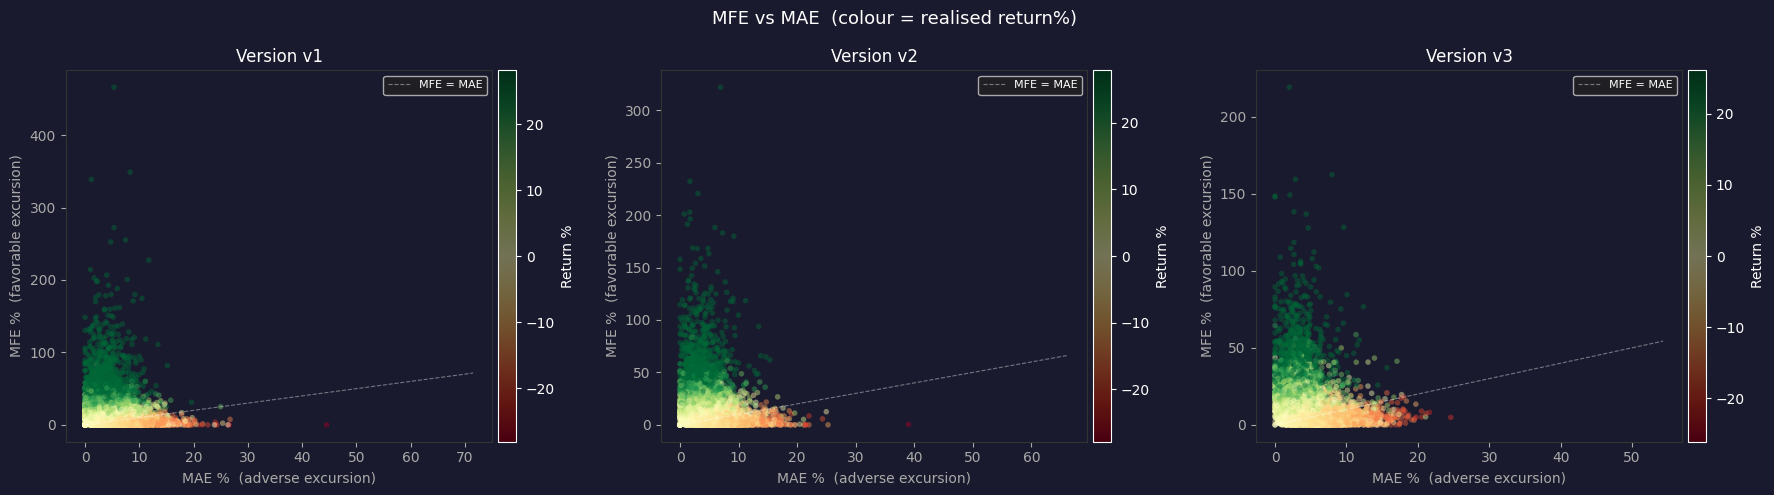

Above diagonal (MFE > MAE): trade moved more in your favour than against.
Losers above diagonal -> stop hit after a favourable move (late reversal).
Winners well above diagonal -> exited before capturing full move (low efficiency).


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#1a1a2e')

for ax, (ver, df) in zip(axes, mfe_mae.items()):
    d = df.dropna(subset=['MFE%', 'MAE%'])
    vmax = d['Return%'].abs().quantile(0.95)
    sc = ax.scatter(
        d['MAE%'], d['MFE%'],
        c=d['Return%'], cmap='RdYlGn', vmin=-vmax, vmax=vmax,
        alpha=0.45, s=16, linewidths=0,
    )
    ax.set_facecolor('#1a1a2e')
    lim = max(d['MAE%'].quantile(0.98), d['MFE%'].quantile(0.98)) * 1.05
    ax.plot([0, lim], [0, lim], 'w--', lw=0.8, alpha=0.4, label='MFE = MAE')
    plt.colorbar(sc, ax=ax, label='Return %', pad=0.01)
    ax.set_xlabel('MAE %  (adverse excursion)', color='#aaa')
    ax.set_ylabel('MFE %  (favorable excursion)', color='#aaa')
    ax.set_title(f'Version {ver}', color='white')
    ax.tick_params(colors='#aaa')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')
    ax.legend(fontsize=8, facecolor='#222', labelcolor='white')

fig.suptitle('MFE vs MAE  (colour = realised return%)', color='white', fontsize=13)
fig.tight_layout()
plt.show()

print('Above diagonal (MFE > MAE): trade moved more in your favour than against.')
print('Losers above diagonal -> stop hit after a favourable move (late reversal).')
print('Winners well above diagonal -> exited before capturing full move (low efficiency).')


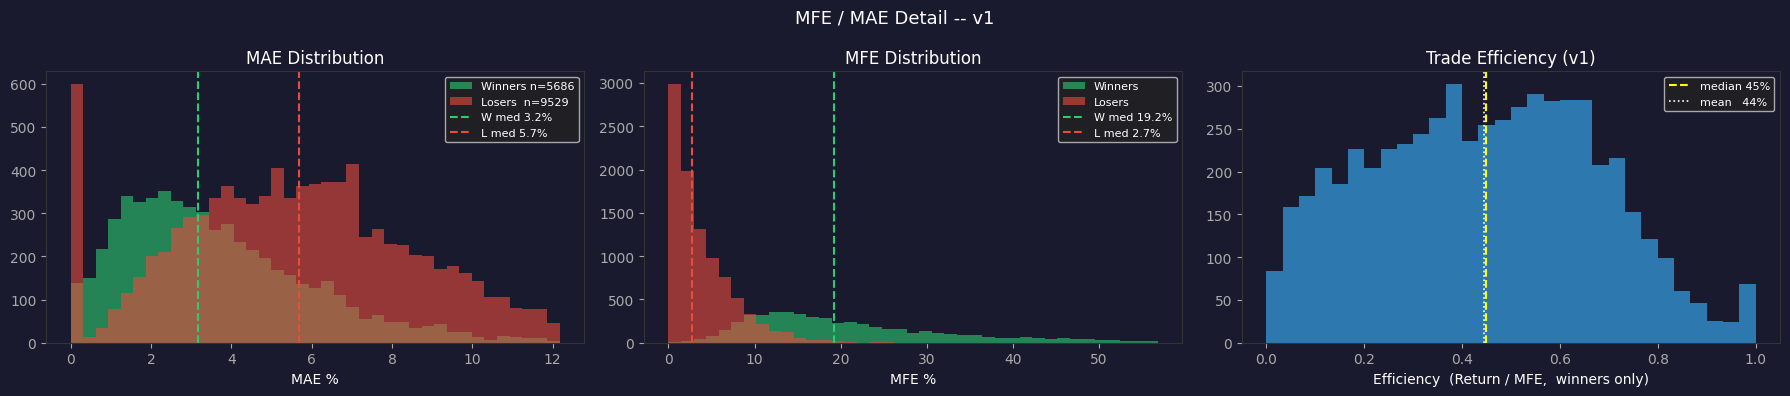

In [ ]:
VER = 'v1'   # change to v2 or v3
df  = mfe_mae[VER]
w   = df[df['Winner']].dropna(subset=['MFE%', 'MAE%'])
l   = df[~df['Winner']].dropna(subset=['MFE%', 'MAE%'])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.patch.set_facecolor('#1a1a2e')
GRN, RED, BLU = '#2ecc71', '#e74c3c', '#3498db'

def _style(ax, title):
    ax.set_facecolor('#1a1a2e')
    ax.set_title(title, color='white')
    ax.tick_params(colors='#aaa')
    ax.legend(facecolor='#222', labelcolor='white', fontsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#333')

bins_mae = np.linspace(0, df['MAE%'].quantile(0.97), 40)
axes[0].hist(w['MAE%'], bins=bins_mae, color=GRN, alpha=0.6, label=f'Winners n={len(w)}')
axes[0].hist(l['MAE%'], bins=bins_mae, color=RED, alpha=0.6, label=f'Losers  n={len(l)}')
axes[0].axvline(w['MAE%'].median(), color=GRN, lw=1.5, ls='--', label=f'W med {w["MAE%"].median():.1f}%')
axes[0].axvline(l['MAE%'].median(), color=RED, lw=1.5, ls='--', label=f'L med {l["MAE%"].median():.1f}%')
axes[0].set_xlabel('MAE %')
_style(axes[0], 'MAE Distribution')

bins_mfe = np.linspace(0, df['MFE%'].quantile(0.97), 40)
axes[1].hist(w['MFE%'], bins=bins_mfe, color=GRN, alpha=0.6, label='Winners')
axes[1].hist(l['MFE%'], bins=bins_mfe, color=RED, alpha=0.6, label='Losers')
axes[1].axvline(w['MFE%'].median(), color=GRN, lw=1.5, ls='--', label=f'W med {w["MFE%"].median():.1f}%')
axes[1].axvline(l['MFE%'].median(), color=RED, lw=1.5, ls='--', label=f'L med {l["MFE%"].median():.1f}%')
axes[1].set_xlabel('MFE %')
_style(axes[1], 'MFE Distribution')

eff = w['Efficiency']
axes[2].hist(eff, bins=30, color=BLU, alpha=0.75, edgecolor='none')
axes[2].axvline(eff.median(), color='yellow', lw=1.5, ls='--', label=f'median {eff.median():.0%}')
axes[2].axvline(eff.mean(),   color='white',  lw=1.2, ls=':',  label=f'mean   {eff.mean():.0%}')
axes[2].set_xlabel('Efficiency  (Return / MFE,  winners only)')
_style(axes[2], f'Trade Efficiency ({VER})')

fig.suptitle(f'MFE / MAE Detail -- {VER}', color='white', fontsize=13)
fig.tight_layout()
plt.show()


In [ ]:
rows = []
for ver, df in mfe_mae.items():
    w = df[df['Winner']].dropna(subset=['MFE%', 'MAE%'])
    l = df[~df['Winner']].dropna(subset=['MFE%', 'MAE%'])

    edge_ratio  = w['MFE%'].mean() / l['MAE%'].mean() if len(l) and l['MAE%'].mean() > 0 else float('nan')
    stop_hint   = l['MAE%'].quantile(0.30) if len(l) else float('nan')
    target_hint = w['MFE%'].quantile(0.40) if len(w) else float('nan')
    trap_pct    = (l['MFE%'] < l['MAE%']).mean() if len(l) else float('nan')

    rows.append({
        'Version':           ver,
        'N trades':          len(df),
        'MFE(W) mean':       f"{w['MFE%'].mean():.1f}%",
        'MAE(W) mean':       f"{w['MAE%'].mean():.1f}%",
        'MFE(L) mean':       f"{l['MFE%'].mean():.1f}%",
        'MAE(L) mean':       f"{l['MAE%'].mean():.1f}%",
        'Edge Ratio':        f"{edge_ratio:.2f}x",
        'Efficiency(W) med': f"{w['Efficiency'].median():.0%}",
        'Suggested Stop':    f"{stop_hint:.1f}%",
        'Suggested Target':  f"{target_hint:.1f}%",
        'Trap trades (L)':   f"{trap_pct:.0%}",
    })

summary_mfe_mae = pd.DataFrame(rows).set_index('Version')
print('=== MFE / MAE SUMMARY ===')
display(summary_mfe_mae.T)

print("""
Interpretation
  Edge Ratio         >1.0 = winners run further than losers hurt you  (>1.5 excellent)
  Efficiency(W) med  % of MFE actually captured on winning trades  (<50% -> exits too early)
  Suggested Stop     MAE 30th pct of losers -- many losers reversed before this depth
  Suggested Target   MFE 40th pct of winners -- conservative take-profit level
  Trap trades (L)    losers where price NEVER moved in your favour (MFE < MAE)
                     high % = bad entries, not just bad timing
""")


=== MFE / MAE SUMMARY ===


Version,v1,v2,v3
N trades,15215,13774,11574
MFE(W) mean,26.5%,24.8%,21.9%
MAE(W) mean,3.7%,3.4%,3.2%
MFE(L) mean,3.8%,3.9%,3.8%
MAE(L) mean,5.9%,6.0%,5.9%
Edge Ratio,4.49x,4.17x,3.70x
Efficiency(W) med,45%,43%,53%
Suggested Stop,4.0%,4.3%,4.3%
Suggested Target,16.3%,15.2%,14.8%
Trap trades (L),67%,71%,75%



Interpretation
  Edge Ratio         >1.0 = winners run further than losers hurt you  (>1.5 excellent)
  Efficiency(W) med  % of MFE actually captured on winning trades  (<50% -> exits too early)
  Suggested Stop     MAE 30th pct of losers -- many losers reversed before this depth
  Suggested Target   MFE 40th pct of winners -- conservative take-profit level
  Trap trades (L)    losers where price NEVER moved in your favour (MFE < MAE)
                     high % = bad entries, not just bad timing



## 9. Strategy Improvements — MFE/MAE Guided

**Diagnoses from Section 8:**

| Problem | Evidence | Root cause |
|---------|----------|------------|
| Low efficiency (~43%) | Winners captured only 43% of MFE | `low_stop_lookback=3-4`: swing low is 3-4% from entry = inside MAE(W) mean (3.8%). Initial stop fires on normal pullbacks, killing winners early. |
| High trap rate (65-70%) | 2/3 of losers NEVER moved in your favour | No volume confirmation — entries trigger on low-volume false breakouts with no buyers behind them. |

**Fixes applied:**
1. `low_stop_lookback`: 3-4 → **12** (swing low of 12 bars sits safely below normal noise)
2. Volume filter: enter only when `volume > SMA(volume, 20) * vol_mult` (confirms genuine breakout demand)

**Note:** core TTM/KAMA/AVWAP signal logic is untouched — edge ratio of 6-7x proves it works.

In [ ]:
VOL_SMA = vbt.IndicatorFactory.from_talib('SMA')

def compute_signals_improved(
    close, high, low, volume,
    vol_period: int   = 20,
    vol_mult:   float = 1.2,
    **kwargs,
):
    """Wraps compute_signals, adding a volume confirmation filter."""
    base = compute_signals(close, high, low, volume, **kwargs)
    vol_avg = VOL_SMA.run(volume, timeperiod=vol_period).real.to_numpy()
    vol_ok  = volume.to_numpy() > vol_avg * vol_mult
    return pd.DataFrame(
        base.to_numpy() & vol_ok,
        index=close.index, columns=close.columns,
    )


WIDER_LOOKBACK = 12   # fix 1: widen initial stop
VOL_MULT       = 1.2  # fix 2: volume confirmation threshold

portfolios_imp = {}
for ver in ['v1', 'v2', 'v3']:
    p = best_params[ver]
    print(f'Running improved {ver} ...')
    entries = compute_signals_improved(
        close, high, low, volume,
        vol_period      = 20,
        vol_mult        = VOL_MULT,
        bb_window                = p['bb_window'],
        bb_multiplier            = p['bb_multiplier'],
        bb_matype                = p['bb_matype'],
        kc_window                = p['kc_window'],
        kc_multiplier            = p['kc_multiplier'],
        kc_atr_period            = p['kc_atr_period'],
        donichan_window          = p.get('donichan_window', 10),
        osc_smoothing_period     = p.get('osc_smoothing_period', 5),
        entry_version            = ver,
        consecutive_neg_threshold= p.get('consecutive_neg_threshold', 7),
        william_vix_period       = p.get('william_vix_period', 20),
        # avwap_window             = p.get('avwap_window', 200),
        use_kama_slope           = True,
        kama_period              = p.get('kama_period', 10),
        kama_fast                = p.get('kama_fast', 2),
        kama_slow                = p.get('kama_slow', 30),
        kama_slope_win           = p.get('kama_slope_win', 5),
        flat_threshold_pct       = p.get('flat_threshold_pct', 1.0),
    )
    exits, sl_stop_df = compute_exits(
        close, high, low,
        atr_multiplier    = p['atr_multiplier'],
        atr_period        = p.get('atr_period', 10),
        low_stop_lookback = WIDER_LOOKBACK,   # fix 1
        entries=entries,
    )
    early_exits = early_exit_signal(close, low, entries, window=5, pct=0.05)
    pf = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits | early_exits,
        freq='1d', group_by=['symbol'],
        cash_sharing=False, sl_stop=sl_stop_df,
    )
    portfolios_imp[ver] = pf
    n_sig = int(entries.sum().sum())
    print(f'  signals={n_sig:,}  trades={int(pf.trades.count().sum()):,}')

print('Improved portfolios done.')


Running improved v1 ...
  signals=43,528  trades=10,749
Running improved v2 ...
  signals=14,796  trades=7,816
Running improved v3 ...
  signals=2,003  trades=1,933
Improved portfolios done.


In [ ]:
# Side-by-side stats: original vs improved
rows_cmp = []
for ver in ['v1', 'v2', 'v3']:
    for label, pf in [(f'{ver} original', portfolios[ver]),
                      (f'{ver} improved', portfolios_imp[ver])]:
        s = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
        rows_cmp.append({
            'Run':              label,
            'N Trades':         int(pf.trades.count().sum()),
            'Sharpe mean':      round(s.mean(), 3),
            'Sharpe median':    round(s.median(), 3),
            'Sortino mean':     round(pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
            'Total Ret mean':   f'{pf.total_return().mean():.1%}',
            'Win Rate':         f'{pf.trades.win_rate().mean():.1%}',
            'Profit Factor':    round(pf.trades.profit_factor().mean(), 3),
            'Max DD mean':      f'{pf.max_drawdown().mean():.1%}',
            'Avg Trade Ret':    f'{pd.Series(pf.trades.returns.mean()).mean():.2%}',
        })

cmp_df = pd.DataFrame(rows_cmp).set_index('Run')
print('=== ORIGINAL vs IMPROVED ===')
display(cmp_df.T)


=== ORIGINAL vs IMPROVED ===


Run,v1 original,v1 improved,v2 original,v2 improved,v3 original,v3 improved
N Trades,15215,10749,13774,7816,11574,1933
Sharpe mean,0.738,0.623,0.652,0.486,0.515,0.125
Sharpe median,0.763,0.615,0.63,0.482,0.5,0.102
Sortino mean,1.168,0.991,1.034,0.79,0.81,0.268
Total Ret mean,530.4%,294.8%,347.8%,126.4%,178.0%,15.8%
Win Rate,38.3%,39.3%,37.4%,38.5%,36.0%,35.3%
Profit Factor,1.582,1.616,1.524,1.627,1.425,1.765
Max DD mean,-47.2%,-43.0%,-45.5%,-37.4%,-43.6%,-22.1%
Avg Trade Ret,2.67%,2.65%,2.35%,2.37%,1.86%,1.27%


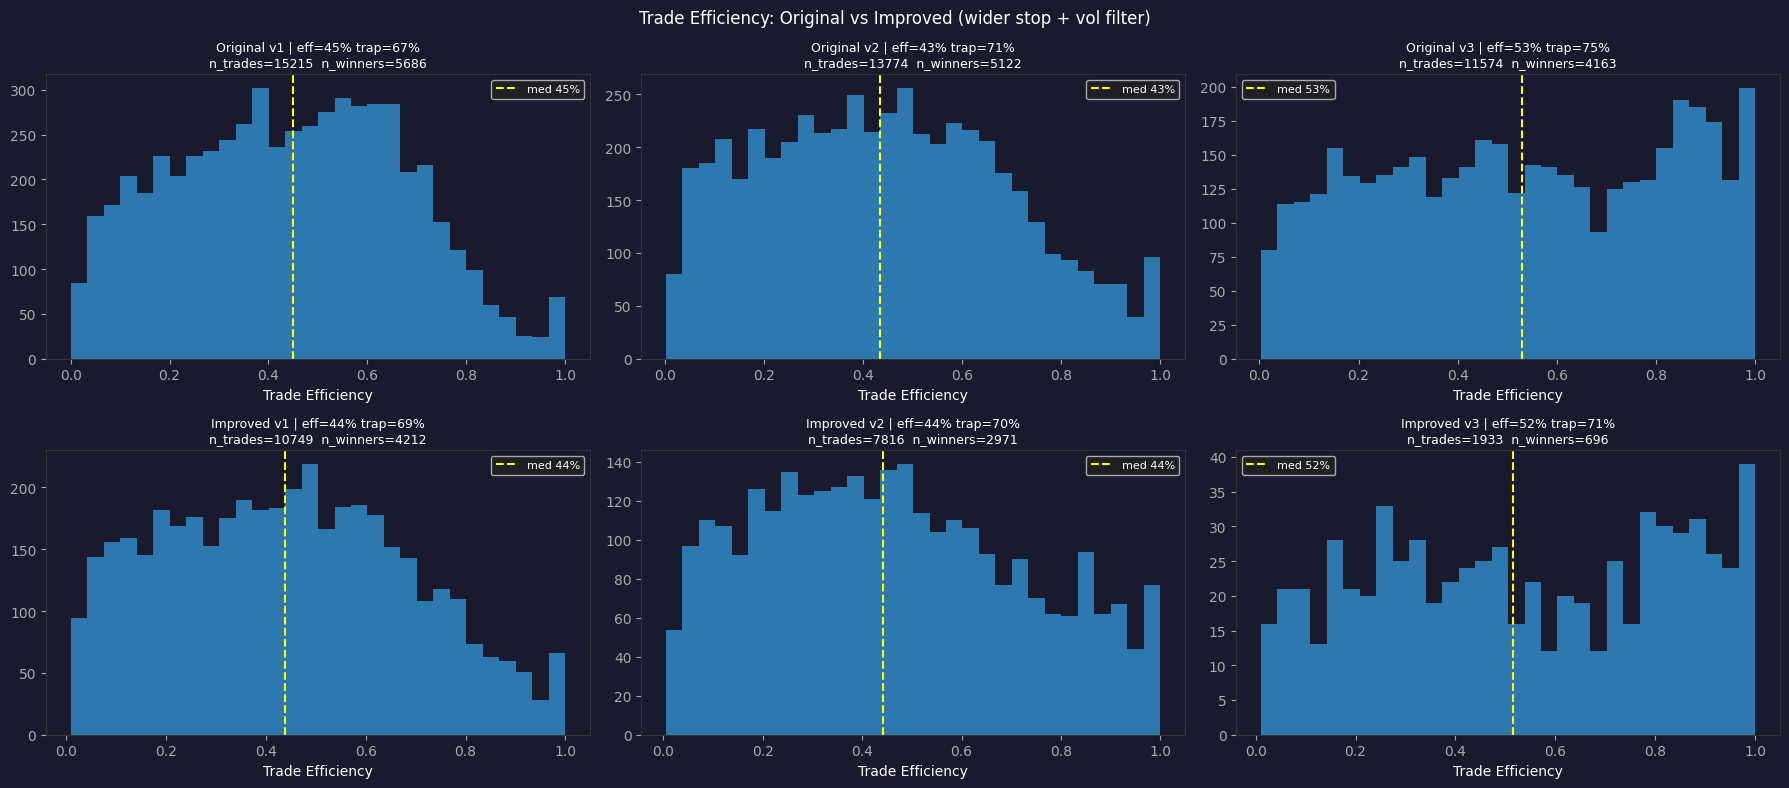

In [ ]:
# MFE/MAE comparison: original vs improved
mfe_mae_imp = {ver: compute_mfe_mae(pf, high, low, close_syms_set)
               for ver, pf in portfolios_imp.items()}

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.patch.set_facecolor('#1a1a2e')

for col, ver in enumerate(['v1', 'v2', 'v3']):
    for row, (label, mm) in enumerate([
        ('Original', mfe_mae[ver]),
        ('Improved', mfe_mae_imp[ver]),
    ]):
        ax  = axes[row][col]
        w   = mm[mm['Winner']].dropna(subset=['MFE%', 'MAE%'])
        l   = mm[~mm['Winner']].dropna(subset=['MFE%', 'MAE%'])
        eff = w['Efficiency']
        GRN, RED = '#2ecc71', '#e74c3c'
        bins = np.linspace(0, mm['Efficiency'].quantile(0.98), 30)
        ax.set_facecolor('#1a1a2e')
        ax.hist(eff.clip(0, 1), bins=30, color='#3498db', alpha=0.75, edgecolor='none')
        ax.axvline(eff.median(), color='yellow', lw=1.5, ls='--',
                   label=f'med {eff.median():.0%}')
        trap = (l['MFE%'] < l['MAE%']).mean()
        ax.set_title(
            f'{label} {ver} | eff={eff.median():.0%} trap={trap:.0%}\n'
            f'n_trades={len(mm)}  n_winners={len(w)}',
            color='white', fontsize=9,
        )
        ax.set_xlabel('Trade Efficiency')
        ax.tick_params(colors='#aaa')
        ax.legend(facecolor='#222', labelcolor='white', fontsize=8)
        for sp in ax.spines.values(): sp.set_edgecolor('#333')

fig.suptitle('Trade Efficiency: Original vs Improved (wider stop + vol filter)',
             color='white', fontsize=12)
fig.tight_layout()
plt.show()


In [ ]:
rows_imp = []
for ver in ['v1', 'v2', 'v3']:
    for label, mm in [(f'{ver} orig', mfe_mae[ver]),
                      (f'{ver} imp',  mfe_mae_imp[ver])]:
        w = mm[mm['Winner']].dropna(subset=['MFE%', 'MAE%'])
        l = mm[~mm['Winner']].dropna(subset=['MFE%', 'MAE%'])
        edge = w['MFE%'].mean() / l['MAE%'].mean() if len(l) and l['MAE%'].mean() > 0 else float('nan')
        trap = (l['MFE%'] < l['MAE%']).mean() if len(l) else float('nan')
        rows_imp.append({
            'Run':             label,
            'N trades':        len(mm),
            'Win Rate':        f"{(mm['Winner'].mean()):.1%}",
            'MFE(W) mean':     f"{w['MFE%'].mean():.1f}%",
            'MAE(W) mean':     f"{w['MAE%'].mean():.1f}%",
            'Edge Ratio':      f"{edge:.2f}x",
            'Efficiency med':  f"{w['Efficiency'].median():.0%}",
            'Trap trades':     f"{trap:.0%}",
        })

delta_df = pd.DataFrame(rows_imp).set_index('Run')
print('=== MFE/MAE BEFORE vs AFTER ===')
display(delta_df.T)

print()
print('Next steps if improvements hold:')
print('  1. Re-run Optuna with low_stop_lookback search range 8-20 (wider)')
print('  2. Add vol_mult/vol_period to Optuna search space')
print('  3. Consider tp_stop at Suggested Target (~22-26%) for partial profit lock')


=== MFE/MAE BEFORE vs AFTER ===


Run,v1 orig,v1 imp,v2 orig,v2 imp,v3 orig,v3 imp
N trades,15215,10749,13774,7816,11574,1933
Win Rate,37.4%,39.2%,37.2%,38.0%,36.0%,36.0%
MFE(W) mean,26.5%,25.2%,24.8%,23.1%,21.9%,19.1%
MAE(W) mean,3.7%,3.7%,3.4%,3.6%,3.2%,3.3%
Edge Ratio,4.49x,4.01x,4.17x,3.89x,3.70x,3.34x
Efficiency med,45%,44%,43%,44%,53%,52%
Trap trades,67%,69%,71%,70%,75%,71%



Next steps if improvements hold:
  1. Re-run Optuna with low_stop_lookback search range 8-20 (wider)
  2. Add vol_mult/vol_period to Optuna search space
  3. Consider tp_stop at Suggested Target (~22-26%) for partial profit lock


### 9.2 Trap Trade Filters — False Breakout & Short-term Momentum

**H1 — False Breakout filter** (from [priceaction.com](https://priceaction.com/price-action-university/strategies/false-break-out/)):
Skip entry if the entry bar is a **false break of resistance**:
`high[t] > max(high[t-N:t-1])` AND `close[t] < max(high[t-N:t-1])`

The bar poked above the N-bar resistance but closed back below it — the classic amateur trap described in the article. Professionals push price back down after the breakout 'bait' is taken.

**H2 — Short-term momentum**: price must already be rising before the signal.
`close > close[3]` (3-bar lookback, tunable)

Both filters are tested individually and combined.

In [ ]:
MAX_FB = vbt.IndicatorFactory.from_talib('MAX')

def compute_signals_h1h2(
    close, high, low, volume,
    use_h1: bool = True,
    h1_lookback: int = 30,
    use_h2: bool = True,
    h2_lookback: int = 3,
    **kwargs,
):
    base = compute_signals(close, high, low, volume, **kwargs)
    mask = np.ones(close.shape, dtype=bool)

    if use_h1:
        high_np  = high.to_numpy()
        close_np = close.to_numpy()
        # rolling N-bar high of the HIGH series, shifted 1 bar = prior resistance level
        hh_np    = MAX_FB.run(high, timeperiod=h1_lookback).real.to_numpy()
        hh_prev  = shift_2d(hh_np, 1)
        # false break: bar poked above resistance but closed back below it
        is_false_break = (high_np > hh_prev) & (close_np < hh_prev)
        mask &= ~is_false_break

    if use_h2:
        close_np   = close.to_numpy()
        close_prev = shift_2d(close_np, h2_lookback)
        mask &= close_np > close_prev

    return pd.DataFrame(base.to_numpy() & mask, index=close.index, columns=close.columns)


VARIANTS = {
    'H1 only':  dict(use_h1=True,  use_h2=False),
    'H2 only':  dict(use_h1=False, use_h2=True),
    'H1+H2':    dict(use_h1=True,  use_h2=True),
}

TARGET_VER = 'v1'
p = best_params[TARGET_VER]
signal_kwargs = dict(
    bb_window=p['bb_window'], bb_multiplier=p['bb_multiplier'], bb_matype=p['bb_matype'],
    kc_window=p['kc_window'], kc_multiplier=p['kc_multiplier'], kc_atr_period=p['kc_atr_period'],
    donichan_window=p.get('donichan_window', 10), osc_smoothing_period=p.get('osc_smoothing_period', 5),
    entry_version=TARGET_VER,
    consecutive_neg_threshold=p.get('consecutive_neg_threshold', 7),
    william_vix_period=p.get('william_vix_period', 20),
    # avwap_window=p.get('avwap_window', 200),
    use_kama_slope=True,
    kama_period=p.get('kama_period', 10), kama_fast=p.get('kama_fast', 2),
    kama_slow=p.get('kama_slow', 30),     kama_slope_win=p.get('kama_slope_win', 5),
    flat_threshold_pct=p.get('flat_threshold_pct', 1.0),
)

pf_variants = {}
for name, flags in VARIANTS.items():
    entries = compute_signals_h1h2(close, high, low, volume, **flags, **signal_kwargs)
    exits, sl_stop_df = compute_exits(
        close, high, low,
        atr_multiplier=p['atr_multiplier'],
        atr_period=p.get('atr_period', 10),
        low_stop_lookback=WIDER_LOOKBACK,
        entries=entries,
    )
    early_exits = early_exit_signal(close, low, entries, window=5, pct=0.05)
    pf = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits | early_exits,
        freq='1d', group_by=['symbol'],
        cash_sharing=False, sl_stop=sl_stop_df,
    )
    pf_variants[name] = pf
    print(f'{name:<12}  signals={int(entries.sum().sum()):>5,}  trades={int(pf.trades.count().sum()):>5,}')

print('Done.')


H1 only       signals=132,391  trades=14,001
H2 only       signals=97,798  trades=14,817
H1+H2         signals=90,294  trades=14,750
Done.


In [ ]:
def _sym_dist(s, round_n=3, pct_fmt=None):
    """Per-symbol series → mean / median / p25 / p75."""
    x = s.replace([np.inf, -np.inf], np.nan).dropna()
    if x.empty:
        return {}
    q = x.quantile([0.25, 0.5, 0.75])

    def _fmt(v):
        if pct_fmt == 'pct':
            return f'{v:.1%}'
        if pct_fmt == 'ret':
            return f'{v:.2%}'
        return round(float(v), round_n)

    return {
        'mean':   _fmt(x.mean()),
        'median': _fmt(q.loc[0.5]),
        'p25':    _fmt(q.loc[0.25]),
        'p75':    _fmt(q.loc[0.75]),
    }


def _pf_compare_row(label, pf):
    sharpe = _sym_dist(pf.sharpe_ratio())
    sortino = _sym_dist(pf.sortino_ratio())
    tot_ret = _sym_dist(pf.total_return(), pct_fmt='pct')
    max_dd = _sym_dist(pf.max_drawdown(), pct_fmt='pct')
    avg_trade = _sym_dist(pd.Series(pf.trades.returns.mean()), pct_fmt='ret')
    win_rate = _sym_dist(pf.trades.win_rate(), pct_fmt='pct')
    profit_factor = _sym_dist(pf.trades.profit_factor(), round_n=3)

    return {
        'Run':              label,
        'N Trades':         int(pf.trades.count().sum()),
        'Sharpe mean':      sharpe.get('mean'),
        'Sharpe median':    sharpe.get('median'),
        'Sharpe P25':       sharpe.get('p25'),
        'Sharpe P75':       sharpe.get('p75'),
        'Sortino mean':     sortino.get('mean'),
        'Sortino P75':      sortino.get('p75'),
        'Total Ret mean':   tot_ret.get('mean'),
        'Total Ret median': tot_ret.get('median'),
        'Total Ret P25':    tot_ret.get('p25'),
        'Total Ret P75':    tot_ret.get('p75'),
        'Win Rate':         win_rate.get('mean'),
        'Win Rate P75':     win_rate.get('p75'),
        'Profit Factor':    profit_factor.get('mean'),
        'Profit Factor P75': profit_factor.get('p75'),
        'Avg Trade Ret':    avg_trade.get('mean'),
        'Avg Trade median': avg_trade.get('median'),
        'Avg Trade P25':    avg_trade.get('p25'),
        'Avg Trade P75':    avg_trade.get('p75'),
        'Max DD mean':      max_dd.get('mean'),
        'Max DD median':    max_dd.get('median'),
        'Max DD P25':       max_dd.get('p25'),
        'Max DD P75':       max_dd.get('p75'),
    }


rows_h = []
baseline_pf = portfolios[TARGET_VER]
all_runs = [('baseline', baseline_pf)] + list(pf_variants.items())

for label, pf in all_runs:
    rows_h.append(_pf_compare_row(label, pf))

h_df = pd.DataFrame(rows_h).set_index('Run')
print(f'=== H1/H2 FILTER COMPARISON  (base version: {TARGET_VER}) ===')
display(h_df.T)

=== H1/H2 FILTER COMPARISON  (base version: v1) ===


Run,baseline,H1 only,H2 only,H1+H2
N Trades,15215,14001,14817,14750
Sharpe mean,0.738,0.724,0.706,0.704
Sharpe median,0.763,0.735,0.72,0.717
Sharpe P25,0.483,0.49,0.444,0.466
Sharpe P75,0.977,0.965,0.951,0.951
Sortino mean,1.168,1.143,1.126,1.123
Sortino P75,1.557,1.543,1.532,1.526
Total Ret mean,530.4%,509.4%,502.4%,455.7%
Total Ret median,282.7%,255.1%,242.1%,234.4%
Total Ret P25,104.5%,97.4%,83.2%,94.6%


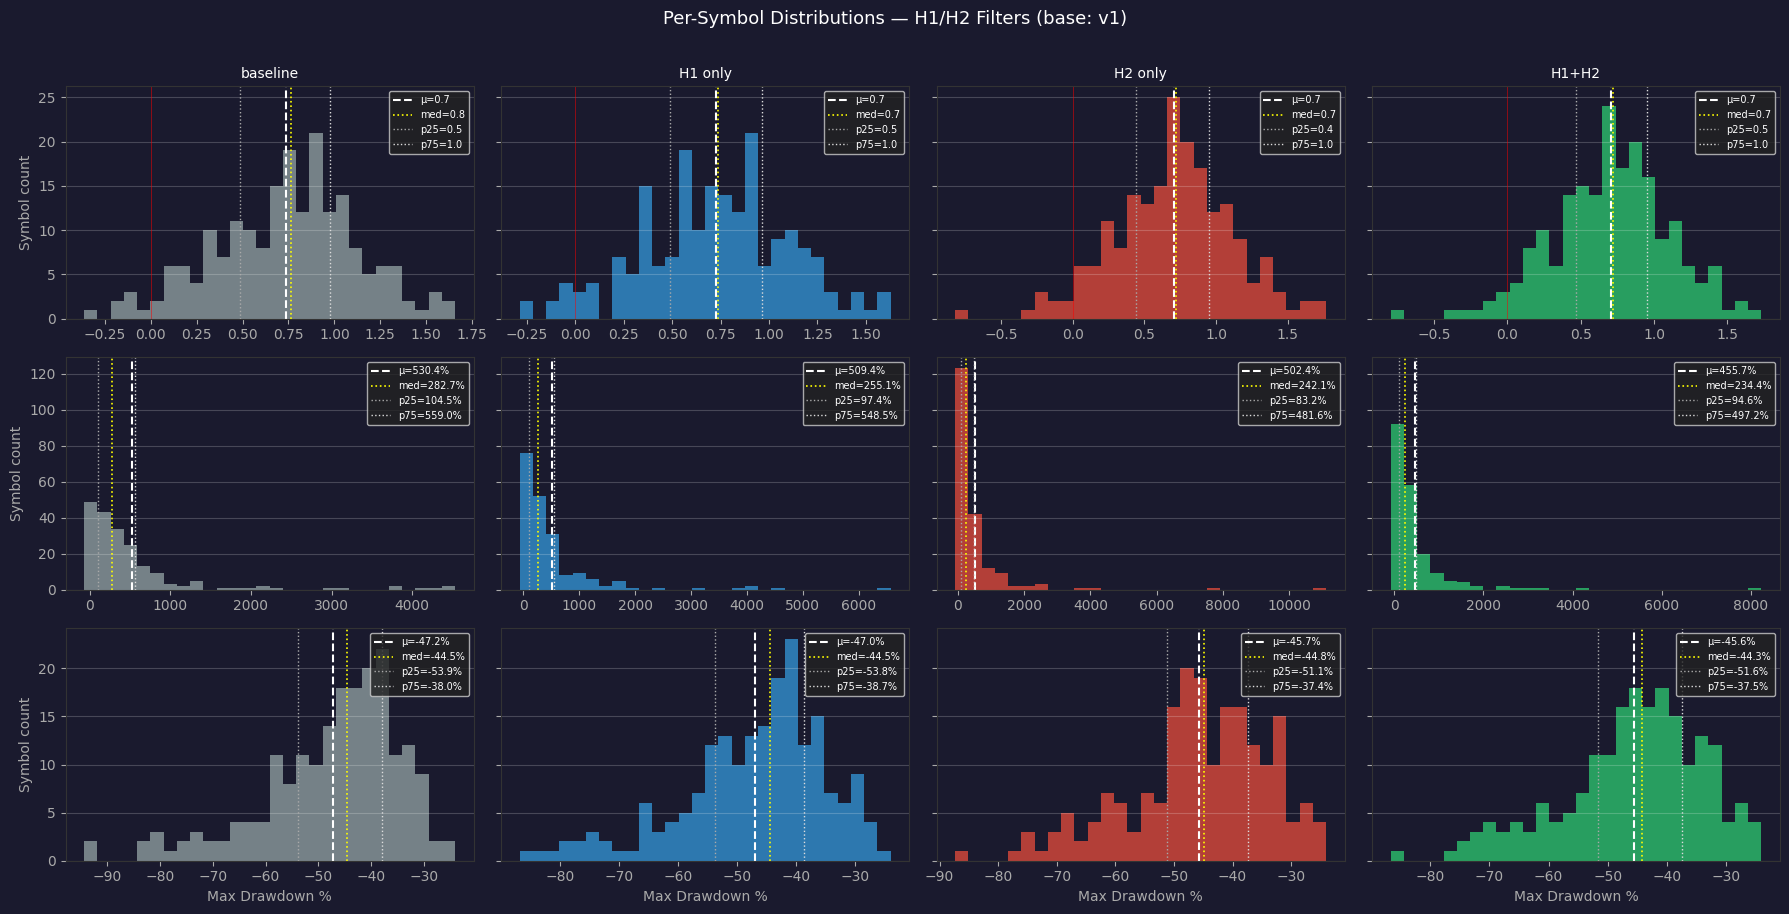

In [ ]:
# ── per-symbol distribution plots: Sharpe / Return / Max DD ─────────────────
def _clean_series(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()


def _style_dist_ax(ax, title=''):
    ax.set_facecolor('#1a1a2e')
    if title:
        ax.set_title(title, fontsize=10, color='white')
    ax.tick_params(colors='#aaa')
    for sp in ax.spines.values():
        sp.set_edgecolor('#333')
    ax.yaxis.grid(True, alpha=0.2)


RUN_COLORS = {
    'baseline': '#95a5a6',
    'H1 only':  '#3498db',
    'H2 only':  '#e74c3c',
    'H1+H2':    '#2ecc71',
}

DIST_METRICS = [
    ('Sharpe',        lambda pf: _clean_series(pf.sharpe_ratio()),              False),
    ('Total Return %', lambda pf: _clean_series(pf.total_return()) * 100,       True),
    ('Max Drawdown %', lambda pf: _clean_series(pf.max_drawdown()) * 100,       True),
]

n_runs = len(all_runs)
fig, axes = plt.subplots(3, n_runs, figsize=(4.5 * n_runs, 9), sharey='row')
if n_runs == 1:
    axes = axes.reshape(3, 1)
fig.patch.set_facecolor('#1a1a2e')

for row, (metric_name, get_vals, is_pct) in enumerate(DIST_METRICS):
    for col, (label, pf) in enumerate(all_runs):
        ax = axes[row, col]
        sv = get_vals(pf)
        color = RUN_COLORS.get(label, '#7f8c8d')
        title = label if row == 0 else ''

        if sv.empty:
            _style_dist_ax(ax, title)
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='#aaa')
            continue

        ax.hist(sv, bins=28, color=color, alpha=0.75, edgecolor='none')
        ax.axvline(sv.mean(), color='white', lw=1.5, ls='--',
                   label=f'μ={sv.mean():.1f}' + ('%' if is_pct else ''))
        ax.axvline(sv.median(), color='yellow', lw=1.2, ls=':',
                   label=f'med={sv.median():.1f}' + ('%' if is_pct else ''))
        ax.axvline(sv.quantile(0.25), color='#aaa', lw=1.0, ls=':',
                   label=f'p25={sv.quantile(0.25):.1f}' + ('%' if is_pct else ''))
        ax.axvline(sv.quantile(0.75), color='#ddd', lw=1.0, ls=':',
                   label=f'p75={sv.quantile(0.75):.1f}' + ('%' if is_pct else ''))
        if metric_name == 'Sharpe':
            ax.axvline(0, color='red', lw=0.7, alpha=0.5)
        _style_dist_ax(ax, title)
        ax.set_xlabel(metric_name if row == 2 else '', color='#aaa')
        if col == 0:
            ax.set_ylabel('Symbol count', color='#aaa')
        ax.legend(fontsize=7, facecolor='#222', labelcolor='white', loc='upper right')

fig.suptitle(
    f'Per-Symbol Distributions — H1/H2 Filters (base: {TARGET_VER})',
    fontsize=13, color='white', y=1.01,
)
fig.tight_layout()
plt.show()

=== MFE/MAE IMPACT ===


Run,H1 only,H2 only,H1+H2,baseline
N trades,14001,14817,14750,15215
Win Rate,39.1%,39.3%,39.2%,37.4%
MFE(W) mean,26.8%,24.0%,24.0%,26.5%
MAE(W) mean,3.4%,3.3%,3.3%,3.7%
MFE(L) mean,4.1%,4.0%,4.0%,3.8%
MAE(L) mean,6.3%,6.1%,6.1%,5.9%
Edge Ratio,4.28x,3.93x,3.94x,4.49x
Efficiency med,44%,44%,44%,45%
Trap trades,69%,72%,72%,67%


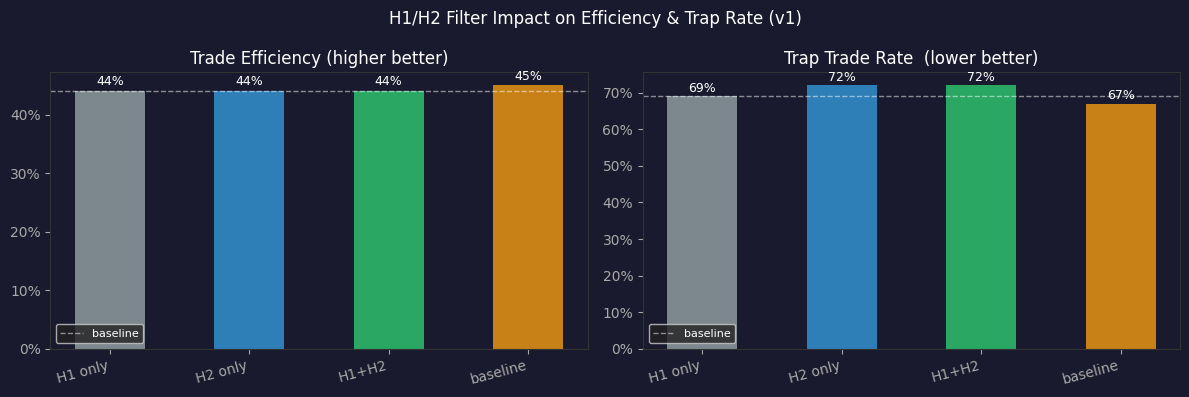

In [ ]:
mfe_mae_variants = {name: compute_mfe_mae(pf, high, low, close_syms_set)
                    for name, pf in pf_variants.items()}
mfe_mae_variants['baseline'] = mfe_mae[TARGET_VER]

rows_mm = []
for label, mm in mfe_mae_variants.items():
    w = mm[mm['Winner']].dropna(subset=['MFE%', 'MAE%'])
    l = mm[~mm['Winner']].dropna(subset=['MFE%', 'MAE%'])
    edge = w['MFE%'].mean() / l['MAE%'].mean() if len(l) and l['MAE%'].mean() > 0 else float('nan')
    trap = (l['MFE%'] < l['MAE%']).mean() if len(l) else float('nan')
    rows_mm.append({
        'Run':            label,
        'N trades':       len(mm),
        'Win Rate':       f"{mm['Winner'].mean():.1%}",
        'MFE(W) mean':    f"{w['MFE%'].mean():.1f}%",
        'MAE(W) mean':    f"{w['MAE%'].mean():.1f}%",
        'MFE(L) mean':    f"{l['MFE%'].mean():.1f}%",
        'MAE(L) mean':    f"{l['MAE%'].mean():.1f}%",
        'Edge Ratio':     f"{edge:.2f}x",
        'Efficiency med': f"{w['Efficiency'].median():.0%}",
        'Trap trades':    f"{trap:.0%}",
    })

mm_df = pd.DataFrame(rows_mm).set_index('Run')
print('=== MFE/MAE IMPACT ===')
display(mm_df.T)

# efficiency + trap rate bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#1a1a2e')
labels = mm_df.index.tolist()
x = np.arange(len(labels))
COLORS_BAR = ['#95a5a6', '#3498db', '#2ecc71', '#f39c12']

eff_vals  = [float(mm_df.loc[l, 'Efficiency med'].strip('%')) / 100 for l in labels]
trap_vals = [float(mm_df.loc[l, 'Trap trades'].strip('%')) / 100 for l in labels]

for ax, vals, title, good_dir in [
    (axes[0], eff_vals,  'Trade Efficiency (higher better)', 'up'),
    (axes[1], trap_vals, 'Trap Trade Rate  (lower better)',  'down'),
]:
    ax.set_facecolor('#1a1a2e')
    bars = ax.bar(x, vals, color=COLORS_BAR[:len(labels)], alpha=0.8, width=0.5)
    ax.axhline(vals[0], color='white', lw=1, ls='--', alpha=0.5, label='baseline')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right', color='#aaa')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_title(title, color='white')
    ax.tick_params(colors='#aaa')
    ax.legend(facecolor='#222', labelcolor='white', fontsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#333')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f'{val:.0%}', ha='center', va='bottom', color='white', fontsize=9)

fig.suptitle(f'H1/H2 Filter Impact on Efficiency & Trap Rate ({TARGET_VER})',
             color='white', fontsize=12)
fig.tight_layout()
plt.show()


## 10. Save Results to HDF5

In [ ]:
# Requires: `best_params` from optimisation (Section 5) and `portfolios` from final backtest (Section 6).
SAVE_VER = 'v1'  # 'v1' | 'v2' | 'v3' - which optimised run to export
pf_opt = portfolios[SAVE_VER]
best = best_params[SAVE_VER]

h5_file   = '../backend/assets/backtest_results_005d.h5'
close_syms = set(close.columns)

# trades
trades_df = pf_opt.trades.records_readable.copy()

def extract_symbol(col):
    if isinstance(col, tuple):
        return next((v for v in col if v in close_syms), str(col))
    return col if isinstance(col, str) and col in close_syms else str(col)

trades_df['symbol']          = trades_df['Column'].apply(extract_symbol)
trades_df['Entry Timestamp'] = pd.to_datetime(trades_df['Entry Timestamp']).dt.strftime('%Y-%m-%d')
trades_df['Exit Timestamp']  = pd.to_datetime(trades_df['Exit Timestamp']).dt.strftime('%Y-%m-%d')

# per-symbol stats
all_metrics = list(pf_opt.metrics.keys())
metrics_ok  = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
stats_df    = pf_opt.stats(metrics=metrics_ok, agg_func=None).reset_index().set_index('symbol')

# best params
params_df = pd.Series(best, name='value').to_frame()

trades_df.to_hdf(h5_file, key='trades',      mode='w')
stats_df.to_hdf(h5_file,  key='stats',       mode='a')
params_df.to_hdf(h5_file, key='best_params', mode='a')

import json
_ttm_json = '../backend/assets/ttm_best_params_005d.json'
with open(_ttm_json, 'w') as f:
    json.dump(best_params, f, indent=2)
print(f'Saved TTM best params (v1/v2/v3) ->  {_ttm_json}')

print(f'Saved {len(trades_df):,} trades  ->  {h5_file}')
print(f'Saved stats for {len(stats_df)} symbols')
print(f'Saved best params ({len(best)} keys)')

trades_df.head()


Saved TTM best params (v1/v2/v3) ->  ../backend/assets/ttm_best_params_005d.json
Saved 15,215 trades  ->  ../backend/assets/backtest_results_005d.h5
Saved stats for 197 symbols
Saved best params (16 keys)


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id,symbol
0,0,"(4, 2.6, 10, AAA)",7.117438,2016-06-27,14.05,0.0,2016-07-11,14.76,0.0,5.053381,0.050534,Long,Closed,0,AAA
1,1,"(4, 2.6, 10, AAA)",6.355316,2016-07-18,16.53,0.0,2016-09-12,16.23,0.0,-1.906595,-0.018149,Long,Closed,1,AAA
2,2,"(4, 2.6, 10, AAA)",6.561500,2016-09-21,15.72,0.0,2016-11-03,14.40,0.0,-8.661180,-0.083969,Long,Closed,2,AAA
3,3,"(4, 2.6, 10, AAA)",6.358385,2016-11-08,14.86,0.0,2016-12-07,14.25,0.0,-3.878615,-0.041050,Long,Closed,3,AAA
4,4,"(4, 2.6, 10, AAA)",6.921848,2017-01-04,13.09,0.0,2017-01-16,12.36,0.0,-5.052949,-0.055768,Long,Closed,4,AAA


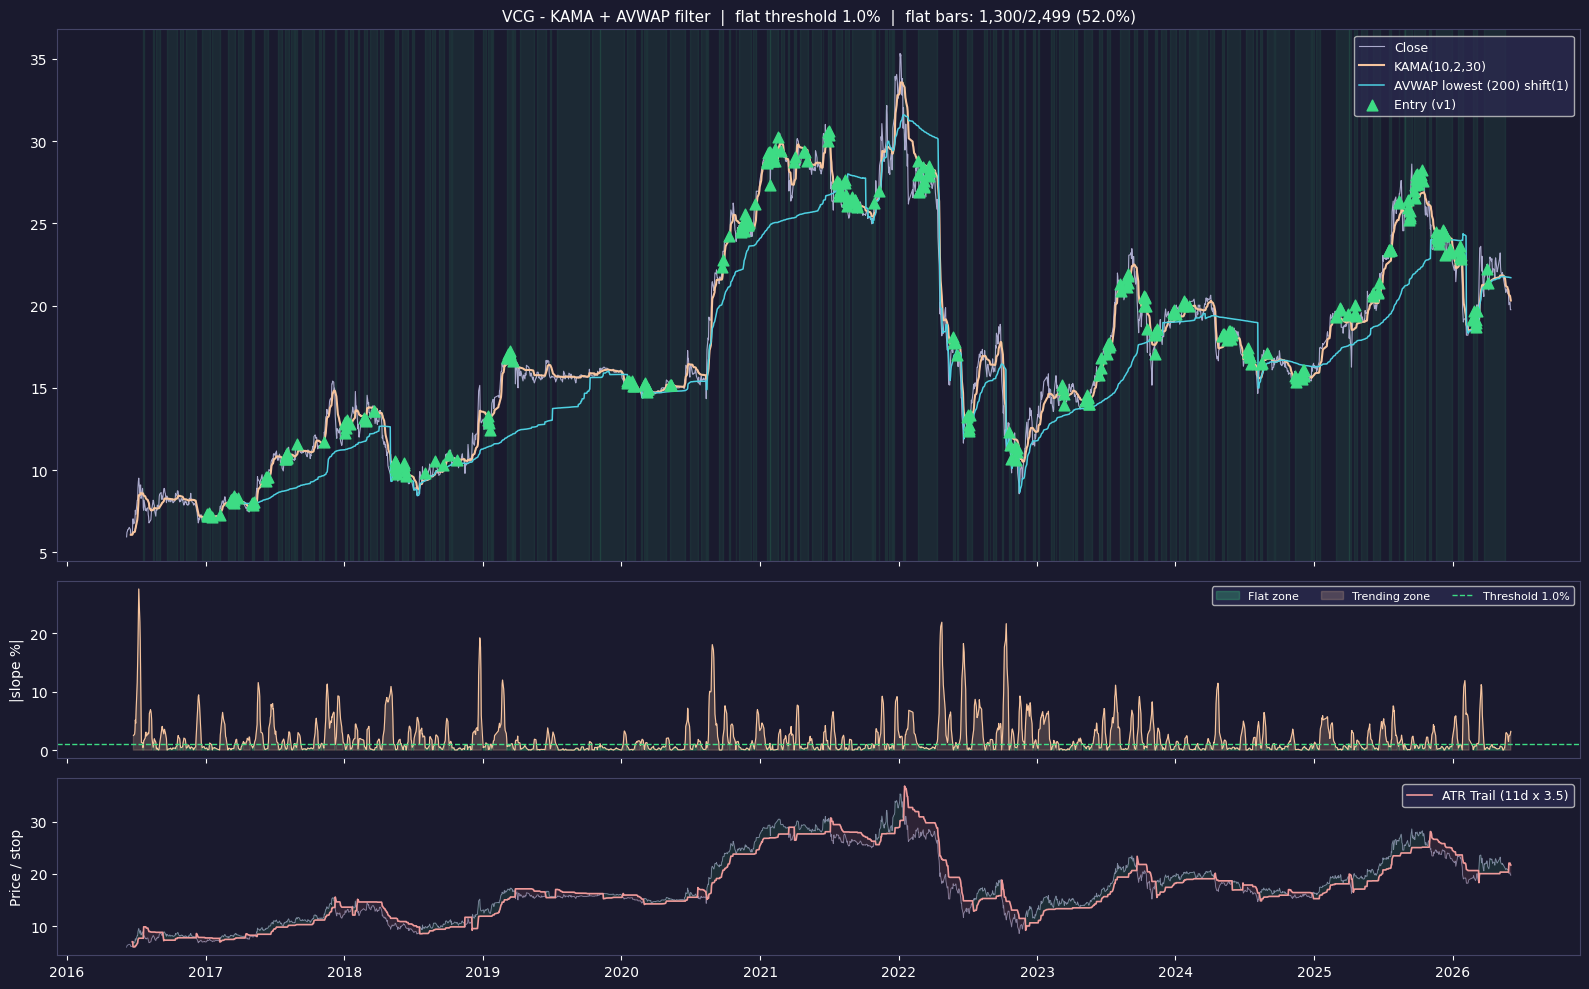

In [ ]:
# KAMA + AVWAP Visual Inspection
# Panel 1: Close price + KAMA line + AVWAP(lowest) + entry signals
# Panel 2: |KAMA slope %| with flatness threshold
# Panel 3: ATR trailing stop
# Run Section 2 first so kama_2d / slope_flat_2d / get_avwap_lowest are defined.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

INSPECT_SYM    = "VCG"
KAMA_PERIOD    = 10
KAMA_FAST      = 2
KAMA_SLOW      = 30
SLOPE_WIN      = 5
FLAT_PCT       = 1.0
ATR_PERIOD     = 11
ATR_MULT       = 3.5
AVWAP_WINDOW   = 200
SHOW_ENTRIES   = True
ENTRY_VERSION  = 'v1'

close_1d = close[[INSPECT_SYM]].to_numpy().astype(np.float64)
high_1d  = high [[INSPECT_SYM]].to_numpy().astype(np.float64)
low_1d   = low  [[INSPECT_SYM]].to_numpy().astype(np.float64)

kama_np = kama_2d(close_1d, KAMA_PERIOD, KAMA_FAST, KAMA_SLOW)
flat_np = slope_flat_2d(kama_np, SLOPE_WIN, FLAT_PCT)
flat_mask = flat_np[:, 0]

import sys, pathlib
sys.path.insert(0, str(pathlib.Path('../backend').resolve()))
from app.services.indicators.trailing_sl import trailing_sl
import talib as _talib

atr_raw   = _talib.ATR(high_1d[:, 0], low_1d[:, 0], close_1d[:, 0], timeperiod=ATR_PERIOD)
atr_trail = trailing_sl(close_1d[:, 0], atr_raw, atr_multiplier=ATR_MULT)

avwap_lowest = get_avwap_lowest(
    close[[INSPECT_SYM]], high[[INSPECT_SYM]], low[[INSPECT_SYM]], volume[[INSPECT_SYM]], AVWAP_WINDOW
)[INSPECT_SYM].shift(1)

if SHOW_ENTRIES:
    _entries_df = compute_signals(
        close[[INSPECT_SYM]], high[[INSPECT_SYM]], low[[INSPECT_SYM]], volume[[INSPECT_SYM]],
        entry_version=ENTRY_VERSION,
        # avwap_window=AVWAP_WINDOW,
        use_kama_slope=True,
        kama_period=KAMA_PERIOD, kama_fast=KAMA_FAST, kama_slow=KAMA_SLOW,
        kama_slope_win=SLOPE_WIN, flat_threshold_pct=FLAT_PCT,
    )
    entry_dates = _entries_df.index[_entries_df[INSPECT_SYM].values]
    entry_prices = close[INSPECT_SYM].reindex(entry_dates).values

pct_slope = np.full(len(kama_np), np.nan)
for i in range(SLOPE_WIN, len(kama_np)):
    prev = kama_np[i - SLOPE_WIN, 0]
    if prev != 0 and not np.isnan(prev):
        pct_slope[i] = abs((kama_np[i, 0] - prev) / prev * 100.0)

idx_range = close.index
DARK = '#1a1a2e'

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1, 1]})
fig.patch.set_facecolor(DARK)
for ax in axes:
    ax.set_facecolor(DARK)
    for spine in ax.spines.values():
        spine.set_color('#444466')
    ax.tick_params(colors='white')
    ax.yaxis.label.set_color('white')

ax1, ax2, ax3 = axes

flat_changes = np.where(np.diff(flat_mask.astype(int)) != 0)[0] + 1
boundaries   = [0] + list(flat_changes) + [len(flat_mask)]
for start, end in zip(boundaries[:-1], boundaries[1:]):
    if flat_mask[start]:
        ax1.axvspan(idx_range[start], idx_range[min(end, len(idx_range)-1)],
                    color='#3ddc84', alpha=0.08)

ax1.plot(idx_range, close[INSPECT_SYM].values, color='#aaaacc', lw=0.8, label='Close')
ax1.plot(idx_range, kama_np[:, 0], color='#f7c59f', lw=1.5,
         label=f'KAMA({KAMA_PERIOD},{KAMA_FAST},{KAMA_SLOW})')
ax1.plot(idx_range, avwap_lowest.values, color='#4dd0e1', lw=1.1,
         label=f'AVWAP lowest ({AVWAP_WINDOW}) shift(1)')

if SHOW_ENTRIES and len(entry_dates):
    ax1.scatter(entry_dates, entry_prices, marker='^', color='#3ddc84',
                s=60, zorder=5, label=f'Entry ({ENTRY_VERSION})')

ax1.set_title(
    f'{INSPECT_SYM} - KAMA + AVWAP filter  |  flat threshold {FLAT_PCT}%  |  '
    f'flat bars: {flat_mask.sum():,}/{len(flat_mask):,} ({flat_mask.mean()*100:.1f}%)',
    color='white', fontsize=11,
)
ax1.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=9)

above = pct_slope >= FLAT_PCT
ax2.fill_between(idx_range, pct_slope, 0,
                 where=~above, color='#3ddc84', alpha=0.25, label='Flat zone')
ax2.fill_between(idx_range, pct_slope, 0,
                 where=above,  color='#f7c59f', alpha=0.20, label='Trending zone')
ax2.plot(idx_range, pct_slope, color='#f7c59f', lw=0.8)
ax2.axhline(FLAT_PCT, color='#3ddc84', lw=1, ls='--', label=f'Threshold {FLAT_PCT}%')
ax2.set_ylabel('|slope %|', color='white')
ax2.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=8, ncol=3)

ax3.plot(idx_range, close[INSPECT_SYM].values, color='#aaaacc', lw=0.6, alpha=0.7)
ax3.plot(idx_range, atr_trail, color='#ef9a9a', lw=1.2, label=f'ATR Trail ({ATR_PERIOD}d x {ATR_MULT})')
above_trail = close[INSPECT_SYM].values > atr_trail
ax3.fill_between(idx_range, close[INSPECT_SYM].values, atr_trail,
                 where=above_trail, color='#3ddc84', alpha=0.10)
ax3.fill_between(idx_range, close[INSPECT_SYM].values, atr_trail,
                 where=~above_trail, color='#e57373', alpha=0.10)
ax3.set_ylabel('Price / stop', color='white')
ax3.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=9)
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
plt.show()


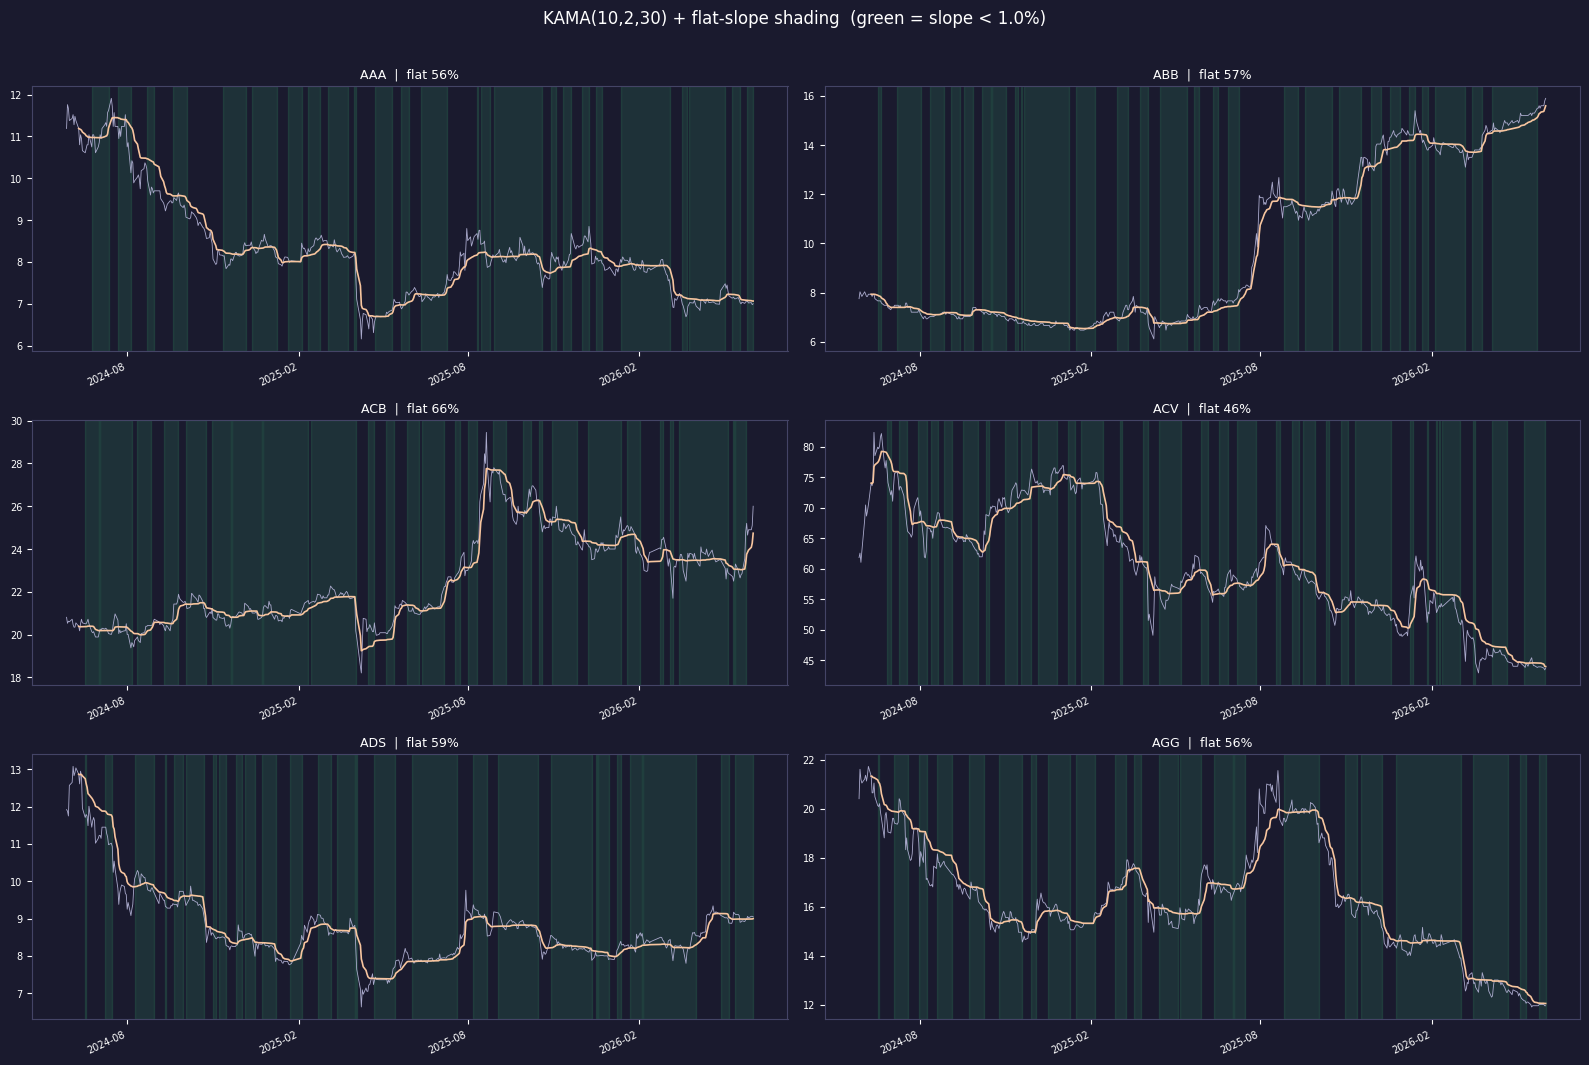

In [ ]:
# ── Multi-Symbol KAMA Grid ────────────────────────────────────────────────────
# Shows KAMA + flat shading for up to N_GRID symbols in a grid layout.

N_GRID      = 6          # symbols to display
GRID_SYMS   = close.columns[:N_GRID].tolist()   # or specify: ['ACB','VCB',...]
KAMA_PERIOD = 10
KAMA_FAST   = 2
KAMA_SLOW   = 30
SLOPE_WIN   = 5
FLAT_PCT    = 1.0
LOOKBACK    = 504        # bars to show (None = all)

ncols = 2
nrows = (len(GRID_SYMS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5), sharex=False)
axes = axes.flatten() if nrows * ncols > 1 else [axes]
fig.patch.set_facecolor('#1a1a2e')

for ax, sym in zip(axes, GRID_SYMS):
    ax.set_facecolor('#1a1a2e')
    for spine in ax.spines.values():
        spine.set_color('#444466')
    ax.tick_params(colors='white', labelsize=7)

    c1d = close[[sym]].to_numpy().astype(np.float64)
    if LOOKBACK:
        c1d = c1d[-LOOKBACK:]
    idx_s = close.index[-len(c1d):]

    kama_s = kama_2d(c1d, KAMA_PERIOD, KAMA_FAST, KAMA_SLOW)
    flat_s = slope_flat_2d(kama_s, SLOPE_WIN, FLAT_PCT)[:, 0]

    # shade flat regions (vectorised)
    changes = np.where(np.diff(flat_s.astype(int)) != 0)[0] + 1
    bounds  = [0] + list(changes) + [len(flat_s)]
    for s, e in zip(bounds[:-1], bounds[1:]):
        if flat_s[s]:
            ax.axvspan(idx_s[s], idx_s[min(e, len(idx_s)-1)],
                       color='#3ddc84', alpha=0.12)

    ax.plot(idx_s, c1d[:, 0],     color='#aaaacc', lw=0.6)
    ax.plot(idx_s, kama_s[:, 0],  color='#f7c59f', lw=1.2)

    flat_pct = flat_s.mean() * 100
    ax.set_title(f'{sym}  |  flat {flat_pct:.0f}%', color='white', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha='right')

# Hide unused axes
for ax in axes[len(GRID_SYMS):]:
    ax.set_visible(False)

fig.suptitle(
    f'KAMA({KAMA_PERIOD},{KAMA_FAST},{KAMA_SLOW}) + flat-slope shading  '
    f'(green = slope < {FLAT_PCT}%)',
    color='white', fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Smart Money Flow Cloud [BOSWaves] — Python port of the Pine Script indicator
# ══════════════════════════════════════════════════════════════════════════════

def _alma_1d(series: np.ndarray, period: int, offset: float, sigma: float) -> np.ndarray:
    """Arnaud Legoux Moving Average (1-D numpy)."""
    m = offset * (period - 1)
    s = period / sigma
    w = np.exp(-((np.arange(period) - m) ** 2) / (2 * s * s))
    w /= w.sum()
    out = np.full(len(series), np.nan)
    for i in range(period - 1, len(series)):
        out[i] = np.dot(w, series[i - period + 1 : i + 1])
    return out


def smart_money_flow_cloud(
    open_df: pd.DataFrame,
    high_df: pd.DataFrame,
    low_df:  pd.DataFrame,
    close_df:pd.DataFrame,
    vol_df:  pd.DataFrame,
    # Core trend
    trend_len:    int   = 34,
    basis_type:   str   = 'EMA',   # 'EMA' | 'ALMA'
    alma_offset:  float = 0.85,
    alma_sigma:   float = 6.0,
    basis_smooth: int   = 3,
    # Smart Money Flow
    mf_len:    int   = 24,
    mf_smooth: int   = 5,
    mf_power:  float = 1.2,
    # Adaptive bands
    atr_len:  int   = 14,
    min_mult: float = 0.9,
    max_mult: float = 2.2,
    # Retest dot cooldown
    dot_cooldown: int = 12,
) -> dict:
    """
    Python port of Smart Money Flow Cloud [BOSWaves].

    Returns a dict of DataFrames (same shape as inputs):
      b_open, b_close       — basis cloud lines
      upper, lower          — adaptive bands
      mf_smooth             — normalised smart money flow  [-1, 1]
      strength              — flow strength                [0, 1]
      mult                  — adaptive ATR multiplier
      last_signal           — 1 = bull, -1 = bear (state machine)
      switch_up/down        — buy/sell signal bars
      bull_dot/bear_dot     — retest dots (with cooldown)
      strength_signed       — tanh-scaled trend strength  [-1, 1]
    """
    results = {}
    syms = close_df.columns

    for sym in syms:
        o = open_df[sym].values.astype(np.float64)
        h = high_df[sym].values.astype(np.float64)
        l = low_df[sym].values.astype(np.float64)
        c = close_df[sym].values.astype(np.float64)
        v = vol_df[sym].values.astype(np.float64)
        n = len(c)
        idx = close_df.index

        # ── Basis ────────────────────────────────────────────────────────────
        if basis_type == 'ALMA':
            raw_o = _alma_1d(o, trend_len, alma_offset, alma_sigma)
            raw_c = _alma_1d(c, trend_len, alma_offset, alma_sigma)
        else:
            raw_o = pd.Series(o, index=idx).ewm(span=trend_len, adjust=False).mean().values
            raw_c = pd.Series(c, index=idx).ewm(span=trend_len, adjust=False).mean().values

        if basis_smooth > 1:
            b_o = pd.Series(raw_o, index=idx).ewm(span=basis_smooth, adjust=False).mean().values
            b_c = pd.Series(raw_c, index=idx).ewm(span=basis_smooth, adjust=False).mean().values
        else:
            b_o, b_c = raw_o, raw_c

        b_main = b_c

        # ── Smart Money Flow ─────────────────────────────────────────────────
        hl = h - l
        clv = np.where(hl == 0, 0.0, ((c - l) - (h - c)) / hl)
        raw_flow = clv * v

        mf_num = pd.Series(raw_flow, index=idx).rolling(mf_len).sum().values
        mf_den = pd.Series(np.abs(raw_flow), index=idx).rolling(mf_len).sum().values
        mf_raw = np.where(mf_den == 0, 0.0, mf_num / mf_den)

        mf_sm = (pd.Series(mf_raw, index=idx).ewm(span=mf_smooth, adjust=False).mean().values
                 if mf_smooth > 1 else mf_raw)

        strength = np.clip(np.power(np.abs(mf_sm), mf_power), 0.0, 1.0)
        mult     = min_mult + (max_mult - min_mult) * strength

        # ── Adaptive bands ───────────────────────────────────────────────────
        atr    = talib.ATR(h, l, c, timeperiod=atr_len)
        upper  = b_main + atr * mult
        lower  = b_main - atr * mult

        # ── Signal state machine ─────────────────────────────────────────────
        long_cond  = (np.roll(c, 1) <= np.roll(upper, 1)) & (c > upper)
        short_cond = (np.roll(c, 1) >= np.roll(lower, 1)) & (c < lower)
        long_cond[0] = short_cond[0] = False

        last_sig = np.zeros(n, dtype=np.int8)
        last_sig[0] = 1 if c[0] >= b_main[0] else -1
        for i in range(1, n):
            if long_cond[i]:   last_sig[i] =  1
            elif short_cond[i]:last_sig[i] = -1
            else:               last_sig[i] = last_sig[i - 1]

        switch_up   = (last_sig ==  1) & (np.roll(last_sig, 1) == -1)
        switch_down = (last_sig == -1) & (np.roll(last_sig, 1) ==  1)
        switch_up[0] = switch_down[0] = False

        # ── Retest dots with cooldown ────────────────────────────────────────
        bear_cond = (last_sig == -1) & (h > b_c)
        bull_cond = (last_sig ==  1) & (l < b_c)
        bear_dot  = np.zeros(n, dtype=bool)
        bull_dot  = np.zeros(n, dtype=bool)
        last_bear = last_bull = -dot_cooldown - 1
        for i in range(n):
            if bear_cond[i] and (dot_cooldown == 0 or i - last_bear >= dot_cooldown):
                bear_dot[i] = True; last_bear = i
            if bull_cond[i] and (dot_cooldown == 0 or i - last_bull >= dot_cooldown):
                bull_dot[i] = True; last_bull = i

        # ── Trend strength (tanh-scaled) ─────────────────────────────────────
        mintick = 0.01
        up_span = np.maximum(upper - b_main, mintick)
        dn_span = np.maximum(b_main - lower, mintick)
        raw_str = np.where(last_sig == 1,
                           (c - b_main) / up_span,
                           -(b_main - c) / dn_span)
        x = np.clip(raw_str * 1.5, -10, 10)
        v_tanh = (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))
        str_signed = pd.Series(v_tanh, index=idx).ewm(span=3, adjust=False).mean().values

        results[sym] = {
            'b_open':         pd.Series(b_o,         index=idx),
            'b_close':        pd.Series(b_c,         index=idx),
            'upper':          pd.Series(upper,        index=idx),
            'lower':          pd.Series(lower,        index=idx),
            'mf_smooth':      pd.Series(mf_sm,        index=idx),
            'strength':       pd.Series(strength,     index=idx),
            'mult':           pd.Series(mult,         index=idx),
            'last_signal':    pd.Series(last_sig,     index=idx),
            'switch_up':      pd.Series(switch_up,    index=idx),
            'switch_down':    pd.Series(switch_down,  index=idx),
            'bull_dot':       pd.Series(bull_dot,     index=idx),
            'bear_dot':       pd.Series(bear_dot,     index=idx),
            'strength_signed':pd.Series(str_signed,   index=idx),
        }

    return results


print('smart_money_flow_cloud() defined')


smart_money_flow_cloud() defined


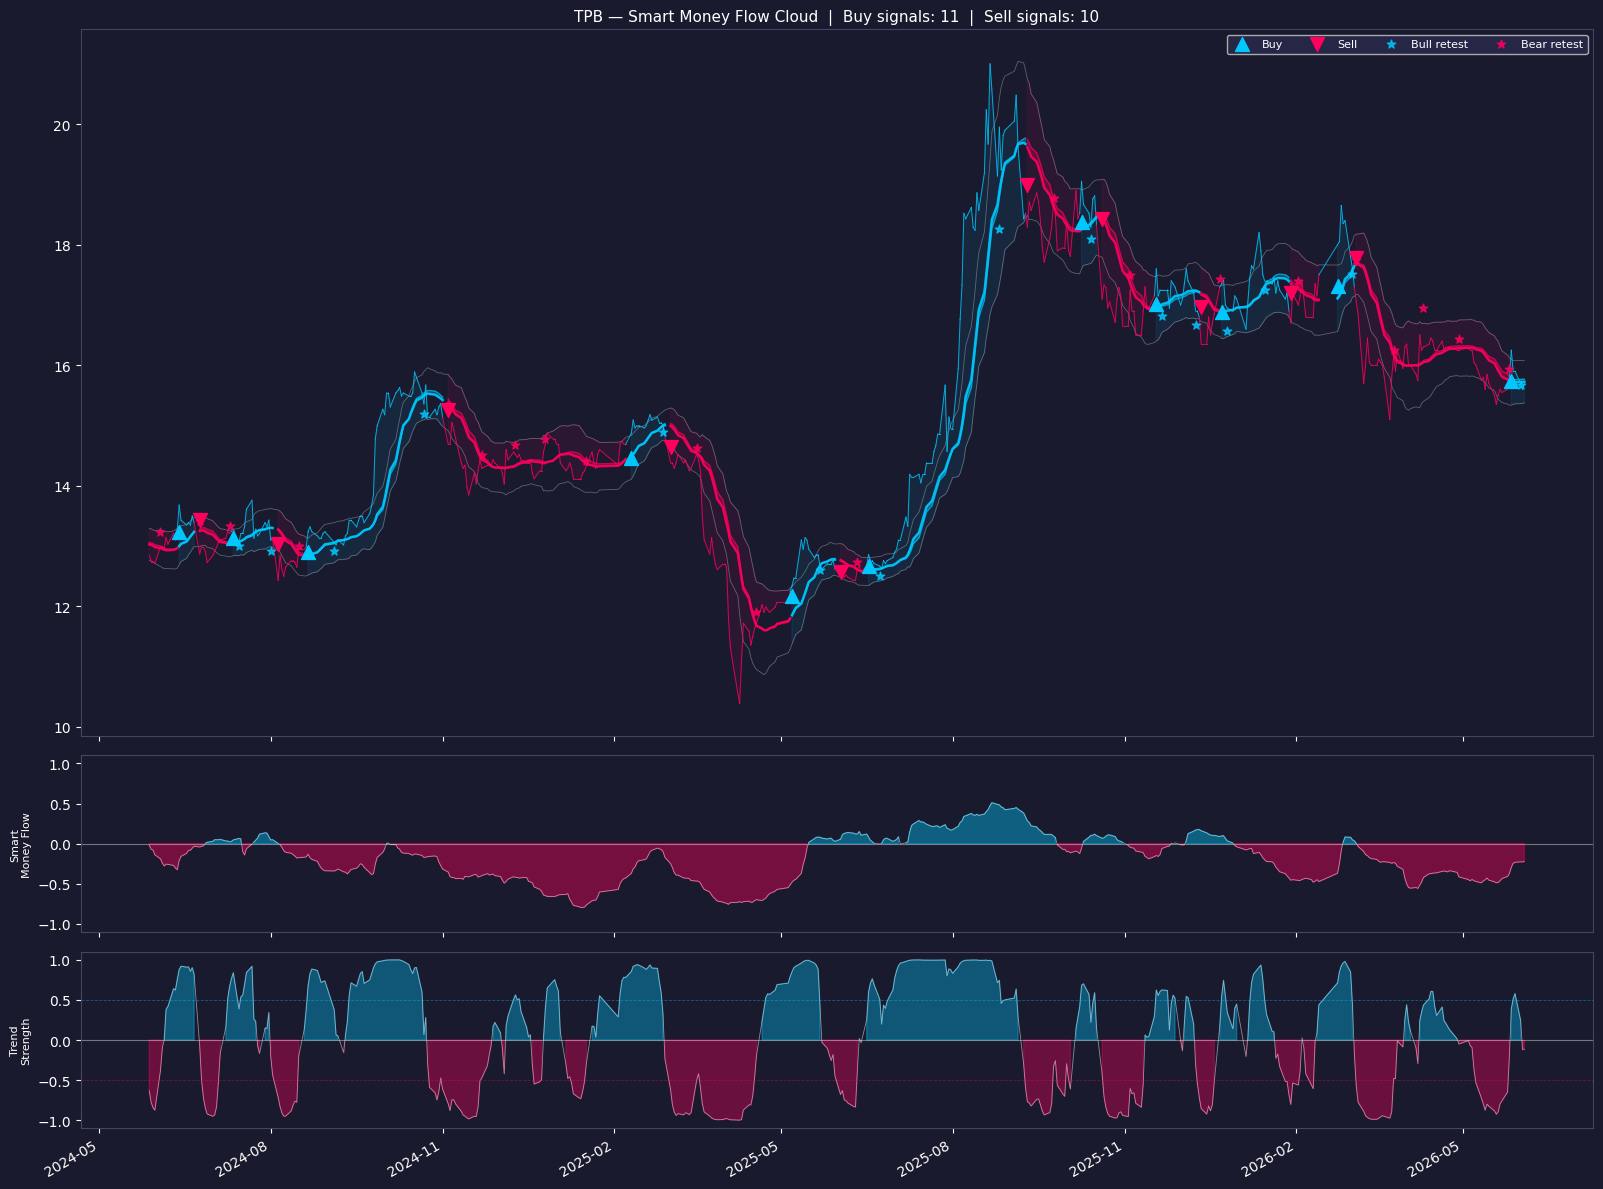


TPB — Latest readings:
  Regime   : BULL 🟢
  MF Flow  : -0.224
  Strength : 16.6%
  Band mult: 1.12x
  Upper    : 16.08  |  Lower: 15.38
  Trend str: -0.114
  Last trade date: 2026-06-03 00:00:00


In [ ]:
def plot_smart_money_flow_cloud(
    open_, high, low, close, volume,
    sym='PAN',
    trend_len=34,
    basis_type='EMA',
    basis_smooth=3,
    mf_len=24,
    mf_smooth=5,
    mf_power=1.2,
    atr_len=14,
    min_mult=0.9,
    max_mult=2.2,
    dot_cooldown=12,
    lookback=504,
):
    """Smart Money Flow Cloud — price cloud, MF flow, and trend strength panels."""
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import warnings
    warnings.filterwarnings("ignore")

    _res = smart_money_flow_cloud(
        open_[[sym]], high[[sym]], low[[sym]],
        close[[sym]], volume[[sym]],
        trend_len=trend_len, basis_type=basis_type, basis_smooth=basis_smooth,
        mf_len=mf_len, mf_smooth=mf_smooth, mf_power=mf_power,
        atr_len=atr_len, min_mult=min_mult, max_mult=max_mult,
        dot_cooldown=dot_cooldown,
    )[sym]

    if lookback:
        sl = slice(-lookback, None)
        _r = {k: v.iloc[sl] for k, v in _res.items()}
        _c = close[sym].iloc[sl]
        _h = high[sym].iloc[sl]
        _l = low[sym].iloc[sl]
    else:
        _r = _res
        _c = close[sym]
        _h = high[sym]
        _l = low[sym]

    idx = _c.index
    sig = _r['last_signal'].values
    BULL_C, BEAR_C = '#00C8FF', '#FF005D'
    DARK = '#1a1a2e'

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
        gridspec_kw={'height_ratios': [4, 1, 1]})
    fig.patch.set_facecolor(DARK)
    for ax in (ax1, ax2, ax3):
        ax.set_facecolor(DARK)
        for sp in ax.spines.values():
            sp.set_color('#444466')
        ax.tick_params(colors='white')

    bull_mask = sig == 1
    for is_bull, color in [(True, BULL_C), (False, BEAR_C)]:
        mask = bull_mask if is_bull else ~bull_mask
        ax1.fill_between(idx, _r['b_open'], _r['b_close'],
                         where=mask, color=color, alpha=0.25, label='_')

    above_lower = _c.values > _r['lower'].values
    below_upper = _c.values < _r['upper'].values
    ax1.fill_between(idx, _c, _r['lower'],
                     where=bull_mask & above_lower, color=BULL_C, alpha=0.08)
    ax1.fill_between(idx, _c, _r['upper'],
                     where=(~bull_mask) & below_upper, color=BEAR_C, alpha=0.08)

    ax1.plot(idx, _r['upper'], color='white', lw=0.6, alpha=0.3)
    ax1.plot(idx, _r['lower'], color='white', lw=0.6, alpha=0.3)

    for is_bull, color in [(True, BULL_C), (False, BEAR_C)]:
        mask = bull_mask if is_bull else ~bull_mask
        masked_c = np.where(mask, _r['b_close'].values, np.nan)
        masked_o = np.where(mask, _r['b_open'].values, np.nan)
        ax1.plot(idx, masked_c, color=color, lw=1.8, alpha=0.9)
        ax1.plot(idx, masked_o, color=color, lw=1.0, alpha=0.6)

    for i in range(1, len(idx)):
        c = BULL_C if sig[i] == 1 else BEAR_C
        ax1.plot(idx[i-1:i+1], _c.values[i-1:i+1], color=c, lw=0.7, alpha=0.8)

    atr_off = (_r['upper'] - _r['lower']).values * 0.08
    up_idx = np.where(_r['switch_up'].values)[0]
    dn_idx = np.where(_r['switch_down'].values)[0]
    ax1.scatter(idx[up_idx], _l.values[up_idx] - atr_off[up_idx],
                marker='^', color=BULL_C, s=100, zorder=6, label='Buy')
    ax1.scatter(idx[dn_idx], _h.values[dn_idx] + atr_off[dn_idx],
                marker='v', color=BEAR_C, s=100, zorder=6, label='Sell')

    bull_d = np.where(_r['bull_dot'].values)[0]
    bear_d = np.where(_r['bear_dot'].values)[0]
    ax1.scatter(idx[bull_d], _l.values[bull_d] - atr_off[bull_d] * 0.5,
                marker='*', color=BULL_C, s=40, alpha=0.8, zorder=5, label='Bull retest')
    ax1.scatter(idx[bear_d], _h.values[bear_d] + atr_off[bear_d] * 0.5,
                marker='*', color=BEAR_C, s=40, alpha=0.8, zorder=5, label='Bear retest')

    n_buy, n_sell = len(up_idx), len(dn_idx)
    ax1.set_title(
        f'{sym} — Smart Money Flow Cloud  |  '
        f'Buy signals: {n_buy}  |  Sell signals: {n_sell}',
        color='white', fontsize=11,
    )
    ax1.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=8, ncol=4)

    mf_vals = _r['mf_smooth'].values
    ax2.fill_between(idx, mf_vals, 0, where=mf_vals >= 0, color=BULL_C, alpha=0.4)
    ax2.fill_between(idx, mf_vals, 0, where=mf_vals < 0, color=BEAR_C, alpha=0.4)
    ax2.plot(idx, mf_vals, color='white', lw=0.6, alpha=0.5)
    ax2.axhline(0, color='white', lw=0.8, alpha=0.4)
    ax2.set_ylabel('Smart\nMoney Flow', color='white', fontsize=8)
    ax2.set_ylim(-1.1, 1.1)

    str_vals = _r['strength_signed'].values
    ax3.fill_between(idx, str_vals, 0, where=str_vals >= 0, color=BULL_C, alpha=0.35)
    ax3.fill_between(idx, str_vals, 0, where=str_vals < 0, color=BEAR_C, alpha=0.35)
    ax3.plot(idx, str_vals, color='white', lw=0.6, alpha=0.5)
    ax3.axhline(0, color='white', lw=0.8, alpha=0.4)
    ax3.axhline(0.5, color=BULL_C, lw=0.6, ls='--', alpha=0.4)
    ax3.axhline(-0.5, color=BEAR_C, lw=0.6, ls='--', alpha=0.4)
    ax3.set_ylabel('Trend\nStrength', color='white', fontsize=8)
    ax3.set_ylim(-1.1, 1.1)

    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right', color='white')

    plt.tight_layout()
    plt.show()

    cur_sig = "BULL 🟢" if _r['last_signal'].iloc[-1] == 1 else "BEAR 🔴"
    print(f"\n{sym} — Latest readings:")
    print(f"  Regime   : {cur_sig}")
    print(f"  MF Flow  : {_r['mf_smooth'].iloc[-1]:+.3f}")
    print(f"  Strength : {_r['strength'].iloc[-1]:.1%}")
    print(f"  Band mult: {_r['mult'].iloc[-1]:.2f}x")
    print(f"  Upper    : {_r['upper'].iloc[-1]:,.2f}  |  Lower: {_r['lower'].iloc[-1]:,.2f}")
    print(f"  Trend str: {_r['strength_signed'].iloc[-1]:+.3f}")
    print(f"  Last trade date: {idx[-1]}")


# ── Config & run ──────────────────────────────────────────────────────────────
plot_smart_money_flow_cloud(
    open_, high, low, close, volume,
    sym='TPB',
    trend_len=34,
    basis_type='ALMA',        # 'EMA' | 'ALMA'
    basis_smooth=3,
    mf_len=24, mf_smooth=5, mf_power=1.2,
    atr_len=14, min_mult=0.9, max_mult=2.2, dot_cooldown=12,
    lookback=504,              # bars to show (None = all)
)


## 11. Log to the Experiment Store

Persists each optimised version as its own run, so they show up in the
`/experiments` page and in `experiments.duckdb`. One run per version: the
store records a single `params` dict per run, so v1/v2/v3 are logged
separately rather than as one sweep. See `docs/experiments.md`.

Re-running creates new run ids; it never overwrites an earlier run.


In [ ]:
# --- Log each optimised version to the experiment store ---------------------
# Requires: `best_params` (Section 5) and `portfolios` (Section 6).
from backend.app.services.experiments import log_experiment

# Section 6b chooses ATR-trailing vs Chandelier per version; fall back to the
# Section 6 portfolios when 6b has not been run in this session.
_final = globals().get('portfolios_final', portfolios)
_exits = globals().get('best_exit_by_version', {})
_selection = globals().get('SELECTION', 'balanced')

runs_005d = {}
for ver in ['v1', 'v2', 'v3']:
    exit_kind = _exits.get(ver, 'ATR trailing')
    runs_005d[ver] = log_experiment(
        _final[ver],
        name=f'backtest_005d_ttm_avwap_{ver}',
        params=best_params[ver],
        tags=['005d', ver, _selection, exit_kind.lower().replace(' ', '-')],
        notebook='notebooks/backtest_005d.ipynb',
        notes=f'TTM breakout squeeze + AVWAP filter, entry {ver}; exit = {exit_kind}',
    )
    print(f'{ver}: {runs_005d[ver].run_id}')

print(f'\nStore: {runs_005d["v1"].base_uri}')


ModuleNotFoundError: No module named 'app'

### Populating the Attribution tab

The runs above carry no `features=`, so the Attribution tab shows outcome
buckets but an empty feature-discrimination table.

**Do not pass the Section 8 MFE/MAE frame as features.** `MFE%`, `MAE%` and
`Efficiency` are measured over the trade's completed life — and `Efficiency`
is derived from `Return%` itself. Feeding them in is lookahead: they would
top the discrimination ranking trivially while saying nothing about what was
knowable at entry.

What belongs there is indicator values **as of the entry bar**, keyed on
`(symbol, entry_dt)` — one column per candidate predictor:

```python
# Example: sample entry-bar indicator values for the trades of one run.
trades = _final['v1'].trades.records_readable
sym = trades['Column'].apply(
    lambda c: next((v for v in c if v in set(close.columns)), None)
    if isinstance(c, tuple) else c
)
entry_dt = pd.to_datetime(trades['Entry Timestamp'])

feats = pd.DataFrame({'symbol': sym, 'entry_dt': entry_dt})
feats['rsi'] = [rsi_df.at[d, s] for s, d in zip(sym, entry_dt)]        # rsi_df: bars x symbols
feats['atr_pct'] = [atr_pct_df.at[d, s] for s, d in zip(sym, entry_dt)]

log_experiment(_final['v1'], name='backtest_005d_ttm_avwap_v1',
               params=best_params['v1'], features=feats.dropna(subset=['symbol']))
```

Every column is prefixed `feat_` in the store, and columns are pooled across
runs with `union_by_name`, so runs with different feature sets compare fine —
the Attribution tab reports per-feature coverage so a sparse one is visible.
